### Analysis of learned plasticity rule that organizes integrating network
Networks initialized with structured input weights, but weights in 'ellipsoid body' are random but fully connected.

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import glob as glob
import matplotlib
import matplotlib.pyplot as plt
import os
from aux import zero_pad, format_plot, format_pc_plot, add_inset_axes
from pathlib import Path
from sklearn.decomposition import PCA
from sklearn import linear_model
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import plotly.offline as pyo
import subprocess
import cv2
from natsort import natsorted

plt.rcParams['font.family'] = 'Helvetica'

DATA_PATHS = [
    'hardcoded_instant_inh_0.90e-4_hard_coded_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8015_2025-07-23_23:44:53.389611',
    'hardcoded_instant_inh_0.91e-4_hard_coded_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8015_2025-07-23_23:47:58.337077',
    'hardcoded_instant_inh_0.92e-4_hard_coded_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8015_2025-07-23_23:50:56.130464',
    'hardcoded_instant_inh_0.93e-4_hard_coded_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8015_2025-07-23_23:53:57.954415',
    'hardcoded_instant_inh_0.94e-4_hard_coded_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8015_2025-07-23_23:56:57.468547',
    'hardcoded_instant_inh_0.95e-4_hard_coded_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8015_2025-07-23_23:59:56.071443',
    'hardcoded_instant_inh_0.96e-4_hard_coded_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8015_2025-07-24_00:02:54.057775',
    'hardcoded_instant_inh_0.97e-4_hard_coded_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8015_2025-07-24_00:05:51.668546',
    'hardcoded_instant_inh_0.98e-4_hard_coded_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8015_2025-07-24_00:08:48.133188',
    'hardcoded_instant_inh_0.99e-4_hard_coded_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8015_2025-07-24_00:11:45.983912',
    'hardcoded_instant_inh_1.00e-4_hard_coded_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8015_2025-07-24_00:14:48.542833',
    'hardcoded_instant_inh_1.01e-4_hard_coded_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8015_2025-07-24_00:17:53.772972',
    'hardcoded_instant_inh_1.02e-4_hard_coded_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8015_2025-07-24_00:21:09.193234',
    'hardcoded_instant_inh_1.03e-4_hard_coded_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8015_2025-07-24_00:24:14.853922',
    'hardcoded_instant_inh_1.04e-4_hard_coded_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8015_2025-07-24_00:27:18.252736',
    'hardcoded_instant_inh_1.05e-4_hard_coded_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8015_2025-07-24_00:30:19.693858',
    'hardcoded_instant_inh_1.06e-4_hard_coded_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8015_2025-07-24_11:25:33.521870',
    'hardcoded_instant_inh_1.07e-4_hard_coded_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8015_2025-07-24_11:30:12.645948',
    'hardcoded_instant_inh_1.08e-4_hard_coded_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8015_2025-07-24_11:34:43.941704',
    'hardcoded_instant_inh_1.09e-4_hard_coded_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8015_2025-07-24_11:39:17.060936',
    'hardcoded_instant_inh_1.10e-4_hard_coded_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8015_2025-07-24_11:43:46.592990',
    'hardcoded_instant_inh_1.11e-4_hard_coded_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8015_2025-07-24_11:48:15.014880',
    'hardcoded_instant_inh_1.12e-4_hard_coded_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8015_2025-07-24_11:52:45.310160',
    'hardcoded_instant_inh_1.13e-4_hard_coded_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8015_2025-07-24_11:57:16.385123',
    'hardcoded_instant_inh_1.14e-4_hard_coded_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8015_2025-07-24_12:01:45.287228',
    'hardcoded_instant_inh_1.15e-4_hard_coded_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8015_2025-07-24_12:06:13.443777',
]

DATA_PATHS = [ './sims_out/' + d for d in DATA_PATHS]

In [2]:
def load_numpy(data_path):
    file_names = glob.glob(data_path)
    data = []
    for file_name in sorted(file_names):
        data_for_file = np.load(file_name)
        data.append(data_for_file)
    return data

def make_path_if_not_exists(path_str):
    Path(path_str).mkdir(parents=True, exist_ok=True)

### Analysis of neural activity

In [3]:
def load_r_and_int_values(rule_path, net_path, last_n=100):
    all_r = np.stack(load_numpy(os.path.join(rule_path, 'activities', net_path)))
    all_int_values = np.stack(load_numpy(os.path.join(rule_path, 'integrated_values', net_path)))
    
    if last_n is not None:
        last_n_r = all_r[-last_n:, 200:, :15]
        all_int_values = all_int_values[-last_n:, :]
    else:
        last_n_r = all_r[:, 200:, :15]
        
    last_n_r = np.transpose(last_n_r, [2, 0, 1])

    return last_n_r, all_int_values

Do PCA on last 50 trials, 15 units in ellipsoid body.

In [4]:
def fit_pca(last_100_r):
    flattened_data = last_100_r.reshape(last_100_r.shape[0], last_100_r.shape[1] * last_100_r.shape[2], order='C')
    pca = PCA()
    pc_activities = pca.fit_transform(flattened_data.T)
    pc_activities = pc_activities.T.reshape(last_100_r.shape, order='C')

    return pc_activities, pca

Learned structure leads to low dimensional activity.

In [ ]:
scale = 0.8
fig, axs = plt.subplots(1, 1, figsize=(6 * scale, 4 * scale))

explained_variance_ratios = pca.explained_variance_ratio_
axs.bar(np.arange(explained_variance_ratios.shape[0]), explained_variance_ratios)
axs.set_xlim(-0.75, 10)
axs.set_ylabel('Variance explained')
axs.set_xlabel('PC')
format_plot(axs)

Retrieve target integrated sums. Keep only the last 100 trials.

In [5]:
def make_tuning_curves(last_100_r, all_int_values):
    scale = 4
    
    inputs_raw = load_numpy(os.path.join(DATA_PATHS[0], 'inputs/net_001_*.npy'))
    inputs = np.concatenate([np.zeros((100, 200, 30)), np.stack(inputs_raw[-100:])], axis=1)
    
    ending_states = np.empty((last_100_r.shape[0], last_100_r.shape[1]))
    
    for i, j in enumerate(np.argsort(all_int_values[:, -1])):
        
        if i % 20 == 0 or i == len(all_int_values[:, -1]) - 1:
            fig, axs = plt.subplots(2, 1, figsize=(1 * scale, 1 * scale))
            axs[0].matshow(inputs[j, :, :15].T, cmap='binary', vmin=0, vmax=5, aspect=10)
            axs[1].matshow(inputs[j, :, 15:].T, cmap='binary', vmin=0, vmax=5, aspect=10)
            for k in range(2):
                axs[k].set_xlabel('Time (ms)', fontsize=16)
                axs[k].set_ylabel('Neuron', fontsize=16)
                axs[k].set_xticks(np.arange(0, 1001, 200), (np.arange(0, 1001, 200) / 10).astype(int))
                axs[k].set_yticks([0, 15])
                axs[k].tick_params(axis='x', bottom=True, top=False, labelbottom=True, labeltop=False)
                axs[k].xaxis.set_label_position('bottom')
                axs[k].tick_params(axis='both', length=6, labelsize=16)
    
            fig, axs = plt.subplots(1, 1, figsize=(1 * scale, 1 * scale))
            axs.matshow(last_100_r[:, j, :], cmap='bwr', vmin=-2, vmax=2, aspect=100)
            axs.set_xlabel('Time (ms)', fontsize=16)
            axs.set_ylabel('Neuron', fontsize=16)
            axs.set_xticks(np.arange(0, 5001, 1000), (np.arange(0, 5001, 1000) / 10).astype(int))
            axs.set_yticks([0, 15])
            axs.tick_params(axis='x', bottom=True, top=False, labelbottom=True, labeltop=False)
            axs.xaxis.set_label_position('bottom')
            axs.tick_params(axis='both', length=6, labelsize=16)
        
    for i, j in enumerate(np.argsort(all_int_values[:, -250])):
        ending_states[:, i] = last_100_r[:, j, -250]
        
    #     fig.savefig(os.path.join(img_path, f'act_{zero_pad(run, 4)}_t_{zero_pad(timestep, 4)}.png'))
    #     plt.close()
    
    scale = 3.5
    fig, axs = plt.subplots(1, 1, figsize=(1 * scale, 1 * scale))
    axs.matshow(ending_states, cmap='bwr', vmin=-2, vmax=2, aspect=4)
    
    format_plot(axs, rightspine=True, topspine=True)
    
    axs.set_xlabel('Integrated sum', fontsize=16)
    axs.set_xticks([0, 100], ['Leftmost', 'Rightmost'])
    axs.set_ylabel('Neuron', fontsize=16)
    axs.set_yticks([0, 14])
    axs.tick_params(axis='both', length=6, labelsize=16)
    
    scale = 2
    fig, axs = plt.subplots(1, 1, figsize=(1.8 * scale, 1 * scale))
    
    import matplotlib.pyplot as plt
    import numpy as np
    
    plasma = plt.get_cmap("plasma")
    colors = [plasma(i / 100)[:3] for i in range(100)]  # 49 to include 0 and 1
    
    for i in range(ending_states.shape[1]):
        axs.plot(np.arange(ending_states.shape[0]), ending_states[:, i], color=colors[i], lw=1)
    
    format_plot(axs)
    
    axs.set_ylabel('Firing rate (Hz)', fontsize=16)
    axs.set_xlabel('Neuron', fontsize=16)
    axs.set_xticks([0, 14])
    axs.set_xlim(0, 14)
    axs.tick_params(axis='both', length=6, labelsize=16)
    

In [19]:
def make_tuning_curves(last_100_r, all_int_values):
    ending_states = np.empty((last_100_r.shape[0], last_100_r.shape[1]))
    int_values_for_ending_states = np.empty((all_int_values.shape[0]))
    for i, j in enumerate(np.argsort(all_int_values[:, -250])):
        ending_states[:, i] = last_100_r[:, j, -250]
        int_values_for_ending_states[i] = all_int_values[j, -250]
    
    scale = 3.5
    fig, axs = plt.subplots(1, 1, figsize=(1 * scale, 1 * scale))
    axs.matshow(ending_states, cmap='bwr', vmin=-2, vmax=2, aspect=4)
    
    format_plot(axs, rightspine=True, topspine=True)
    
    axs.set_xlabel('Integrated sum', fontsize=16)
    axs.set_xticks([0, 100], ['Leftmost', 'Rightmost'])
    axs.set_ylabel('Neuron', fontsize=16)
    axs.set_yticks([0, 14])
    axs.tick_params(axis='both', length=6, labelsize=16)
    
    scale = 2
    fig, axs = plt.subplots(1, 1, figsize=(2.3 * scale, 1 * scale))
    
    plasma = plt.get_cmap("plasma")
    int_min, int_max = int_values_for_ending_states.min(), int_values_for_ending_states.max()
    colors = [plasma((int_values_for_ending_states[i] - int_min) / (int_max - int_min))[:3] for i in range(100)]  # 49 to include 0 and 1
    
    for i in range(ending_states.shape[1]):
        axs.plot(np.arange(ending_states.shape[0]), ending_states[:, i], color=colors[i], lw=1)

    norm = matplotlib.colors.Normalize(vmin=int_min, vmax=int_max)
    sm = matplotlib.cm.ScalarMappable(cmap=plasma, norm=norm)
    sm.set_array([])  # Only needed for older versions of matplotlib
    cbar = fig.colorbar(sm, ax=axs, orientation='vertical', pad=0.02)
    cbar.set_label("Integrated value")
    format_plot(cbar.ax)
    
    format_plot(axs)
    
    axs.set_ylabel('Firing rate (Hz)', fontsize=16)
    axs.set_xlabel('Neuron', fontsize=16)
    axs.set_xticks([0, 14])
    axs.set_xlim(0, 14)
    axs.tick_params(axis='both', length=6, labelsize=16)

In [20]:
from matplotlib import gridspec

def make_stability_plot(last_100_r, all_int_values):
    scale = 4

    if all_int_values.shape[-1] < last_100_r.shape[-1]:
        all_int_values = np.concatenate([
            all_int_values,
            all_int_values[:,-1:] * np.ones((all_int_values.shape[0], last_100_r.shape[-1] - all_int_values.shape[-1])),
        ], axis=1)

    def normed_loc(raster):
        total_activity = raster.sum(axis=0)
        raster_normed = np.divide(
            raster,
            total_activity[None, ...],
            where=total_activity != 0,
            out=np.zeros_like(raster)
        )
        ordered_indices = np.argsort(raster, axis=0)
        max_5_indices = ordered_indices[-13:, :]
        x = np.arange(raster_normed.shape[0])
        cols = np.arange(raster.shape[1])[None, :]
        locs = np.einsum(
            'ij,ij->j',
            x[max_5_indices],
            raster_normed[max_5_indices, cols],
        )
        return locs

    all_final_traj = []

    # Create a figure with 2 columns: main plot and histogram
    fig = plt.figure(figsize=(2.5 * scale, 1 * scale))
    gs = gridspec.GridSpec(1, 2, width_ratios=[4, 1], wspace=0.05)
    ax_main = fig.add_subplot(gs[0])
    ax_hist = fig.add_subplot(gs[1], sharey=ax_main)

    sorted_int_values = []

    for i, j in enumerate(np.argsort(all_int_values[:, -1])):
        traj = normed_loc(last_100_r[:, j, :])
        all_final_traj.append(traj[-1])
        cbar = ax_main.scatter(
            np.arange(all_int_values.shape[1]),
            traj,
            alpha=0.2,
            c=all_int_values[j, :],
            s=0.05,
            cmap='plasma'
        )
        
        sorted_int_values.append(all_int_values[j, :])

    # Main plot formatting
    ax_main.set_xlabel('Time (ms)', fontsize=16)
    ax_main.set_ylabel('Bump location', fontsize=16)
    ax_main.set_xticks(np.arange(0, 1301, 1000))
    ax_main.set_xticklabels((np.arange(0, 1301, 1000) / 10).astype(int))
    ax_main.set_yticks([0, 15], [0, 15])
    ax_main.set_ylim(-1, 16)
    ax_main.tick_params(axis='both', length=6, labelsize=14)
    format_plot(ax_main)

    # Histogram on the right (rotated)
    ax_hist.hist(all_final_traj, bins=30, orientation='horizontal', color='gray')
    ax_hist.set_xlabel('Count', fontsize=16)
    ax_hist.tick_params(axis='x', labelsize=14)
    ax_hist.tick_params(axis='y', labelleft=False)  # Hide y-axis labels to avoid duplication
    format_plot(ax_hist)

    plt.show()

    fig, axs = plt.subplots(1, 1, figsize=(1 * scale, 1 * scale))

    # axs.plot([-m, m], [-m, m], color='black', zorder=0)
    axs.scatter(np.stack(sorted_int_values)[:, -1], all_final_traj, s=30, zorder=1, facecolor='red', edgecolor='red', alpha=0.2)
    # axs.set_xlim(-m, m)
    # axs.set_ylim(-m, m)
    # axs.set_xticks([-100, 0, 100])
    # axs.set_yticks([-100, 0, 100])
    
    format_plot(axs)

    axs.set_xlabel(r'$y$', fontsize=16)
    axs.set_ylabel(r'Bump location', fontsize=16)
    # axs.set_title('Predicted vs true integrated sums', fontsize=16)
    axs.tick_params(axis='both', length=6, labelsize=16)
    

Axes(0.125,0.11;0.775x0.77)
Axes(0.78375,0.11;0.11625x0.77)
Axes(0.125,0.11;0.64325x0.77)
Axes(0.125,0.11;0.604878x0.77)
Axes(0.74878,0.11;0.15122x0.77)


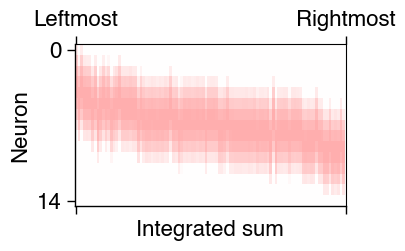

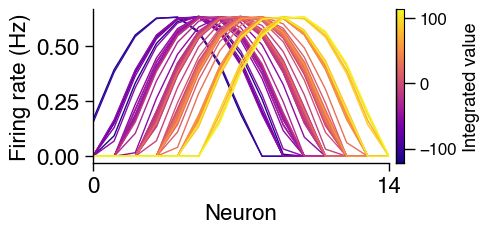

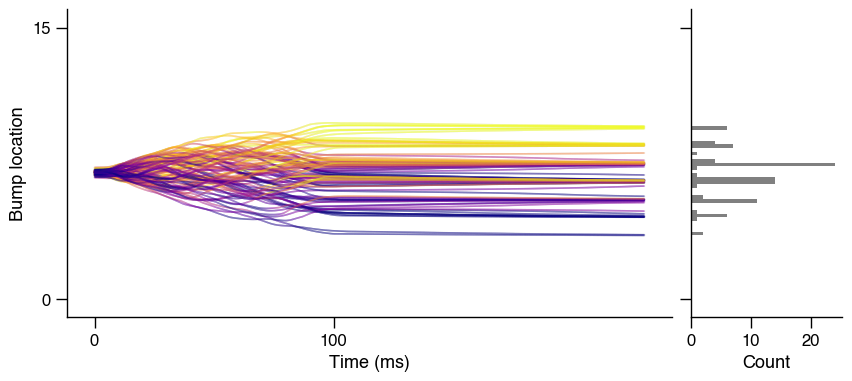

Axes(0.125,0.11;0.775x0.77)
Axes(0.125,0.11;0.775x0.77)
Axes(0.78375,0.11;0.11625x0.77)
Axes(0.125,0.11;0.64325x0.77)
Axes(0.125,0.11;0.604878x0.77)
Axes(0.74878,0.11;0.15122x0.77)


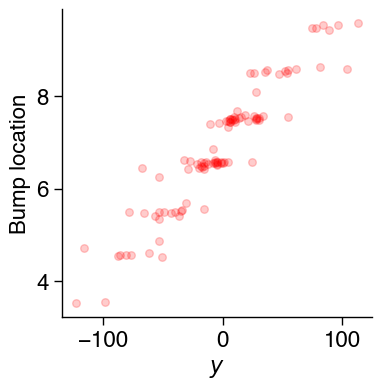

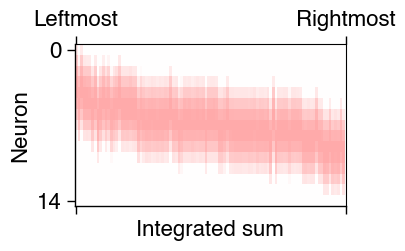

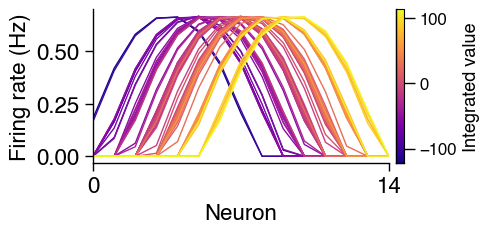

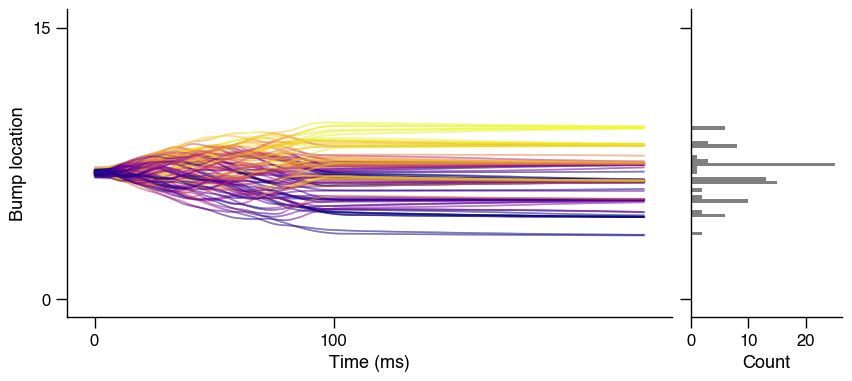

Axes(0.125,0.11;0.775x0.77)
Axes(0.125,0.11;0.775x0.77)
Axes(0.78375,0.11;0.11625x0.77)
Axes(0.125,0.11;0.64325x0.77)
Axes(0.125,0.11;0.604878x0.77)
Axes(0.74878,0.11;0.15122x0.77)


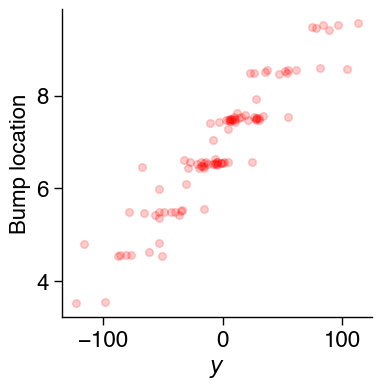

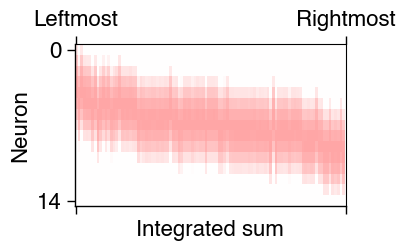

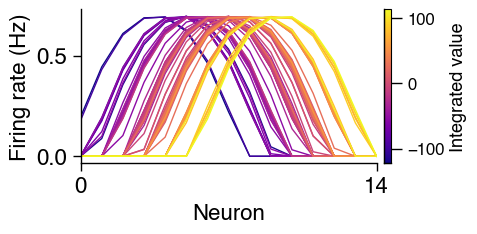

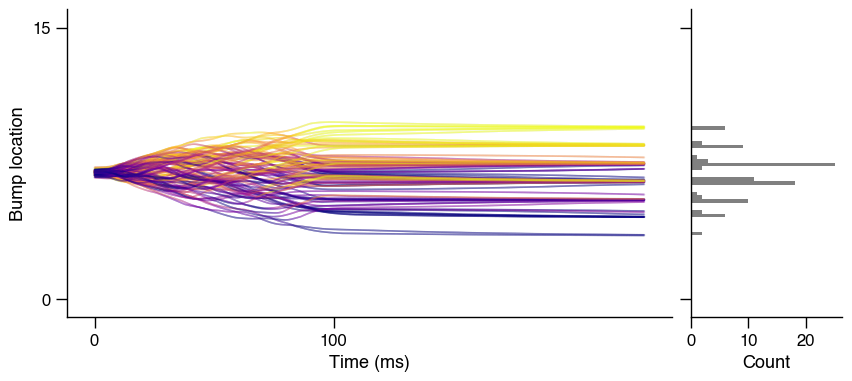

Axes(0.125,0.11;0.775x0.77)
Axes(0.125,0.11;0.775x0.77)
Axes(0.78375,0.11;0.11625x0.77)
Axes(0.125,0.11;0.64325x0.77)
Axes(0.125,0.11;0.604878x0.77)
Axes(0.74878,0.11;0.15122x0.77)


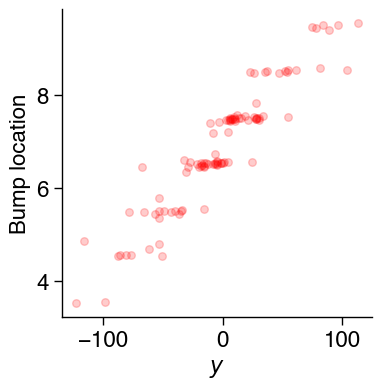

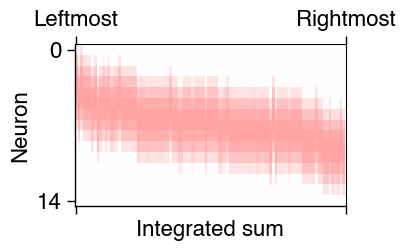

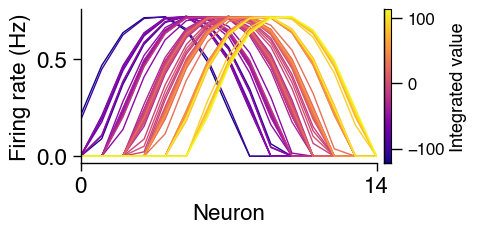

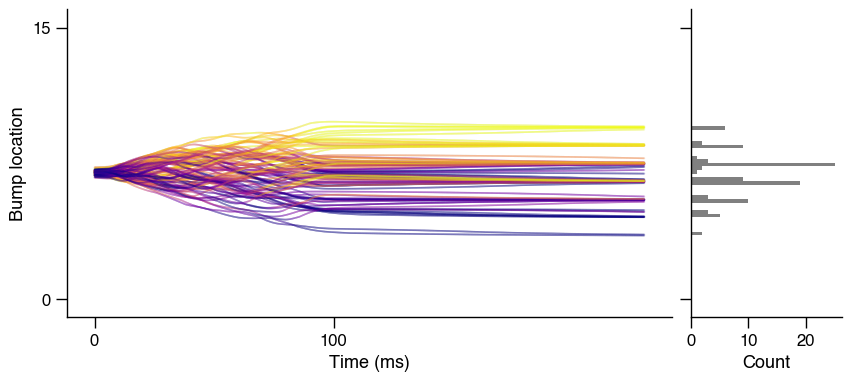

Axes(0.125,0.11;0.775x0.77)
Axes(0.125,0.11;0.775x0.77)
Axes(0.78375,0.11;0.11625x0.77)
Axes(0.125,0.11;0.64325x0.77)
Axes(0.125,0.11;0.604878x0.77)
Axes(0.74878,0.11;0.15122x0.77)


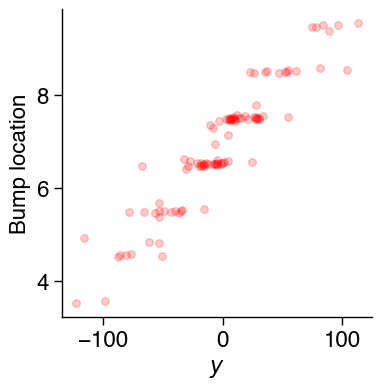

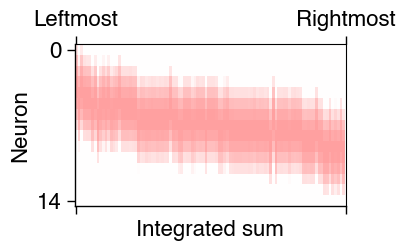

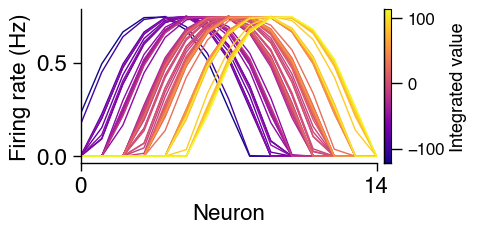

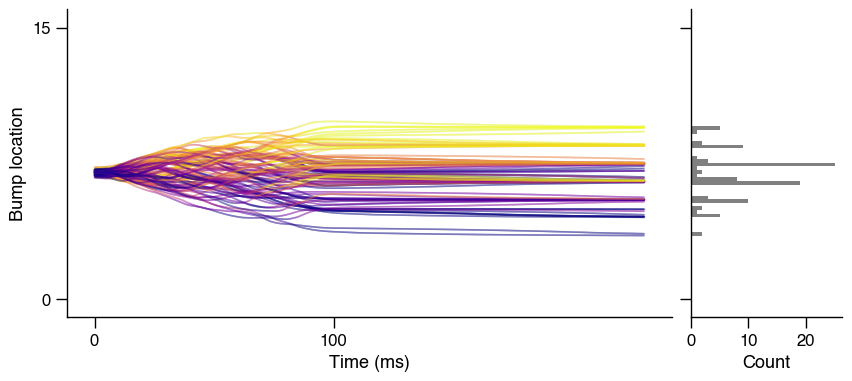

Axes(0.125,0.11;0.775x0.77)
Axes(0.125,0.11;0.775x0.77)
Axes(0.78375,0.11;0.11625x0.77)
Axes(0.125,0.11;0.64325x0.77)
Axes(0.125,0.11;0.604878x0.77)
Axes(0.74878,0.11;0.15122x0.77)


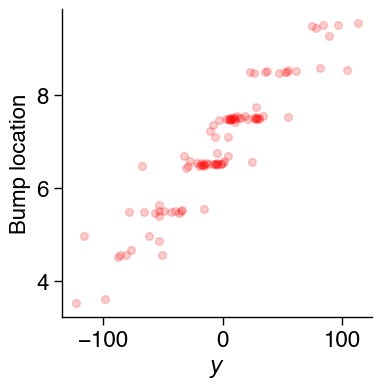

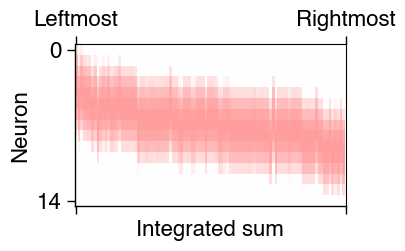

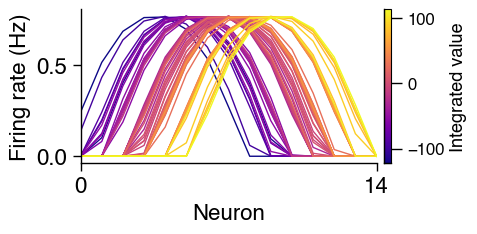

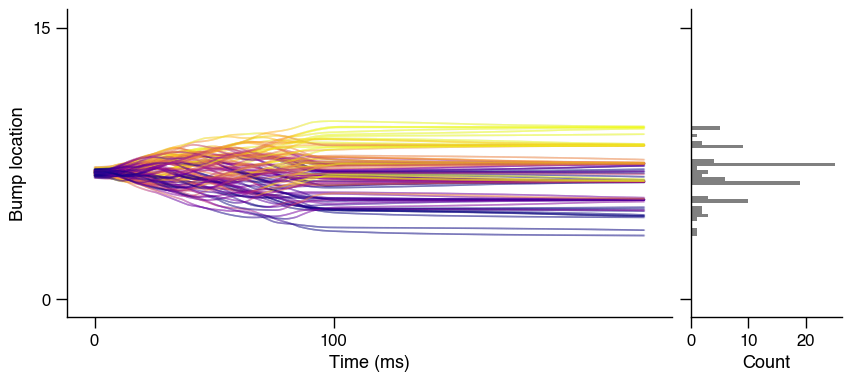

Axes(0.125,0.11;0.775x0.77)
Axes(0.125,0.11;0.775x0.77)
Axes(0.78375,0.11;0.11625x0.77)
Axes(0.125,0.11;0.64325x0.77)
Axes(0.125,0.11;0.604878x0.77)
Axes(0.74878,0.11;0.15122x0.77)


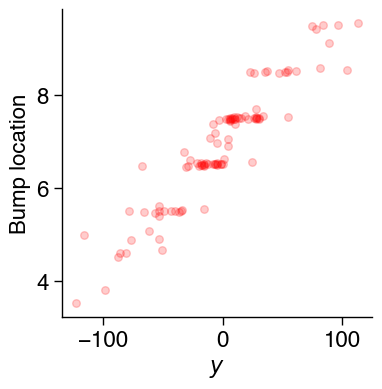

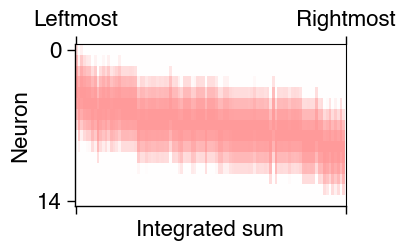

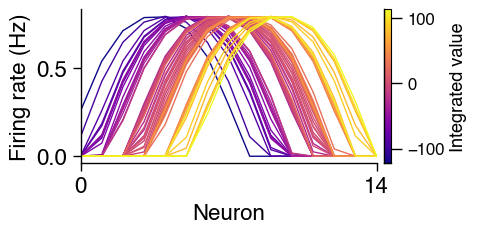

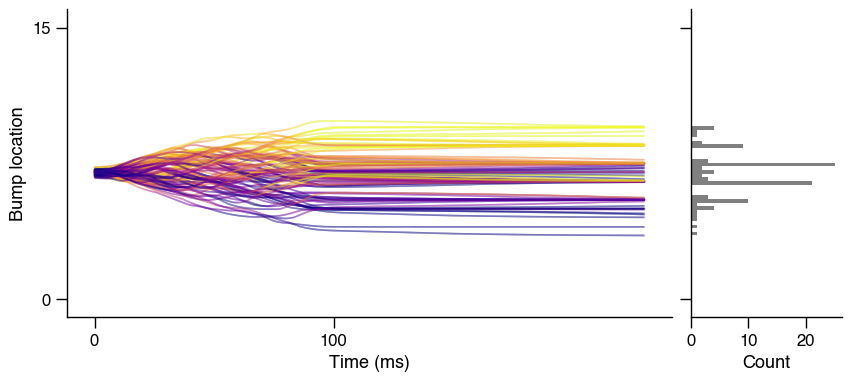

Axes(0.125,0.11;0.775x0.77)
Axes(0.125,0.11;0.775x0.77)
Axes(0.78375,0.11;0.11625x0.77)
Axes(0.125,0.11;0.64325x0.77)
Axes(0.125,0.11;0.604878x0.77)
Axes(0.74878,0.11;0.15122x0.77)


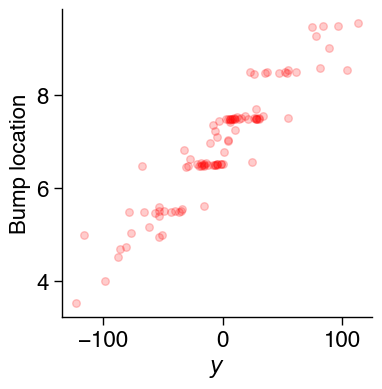

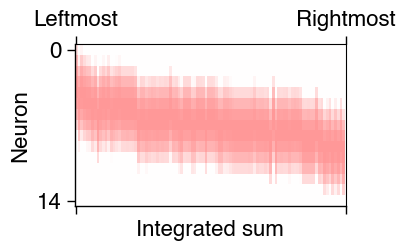

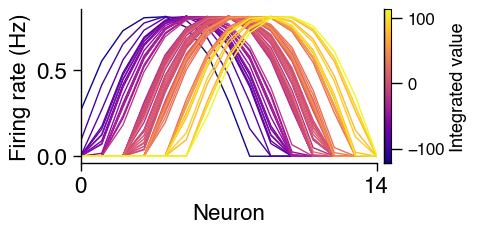

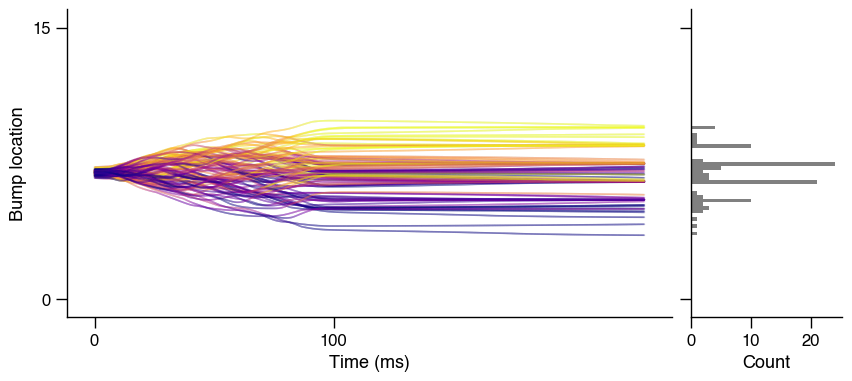

Axes(0.125,0.11;0.775x0.77)
Axes(0.125,0.11;0.775x0.77)
Axes(0.78375,0.11;0.11625x0.77)
Axes(0.125,0.11;0.64325x0.77)
Axes(0.125,0.11;0.604878x0.77)
Axes(0.74878,0.11;0.15122x0.77)


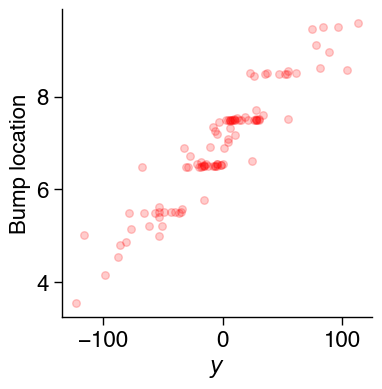

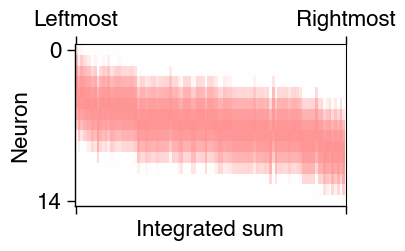

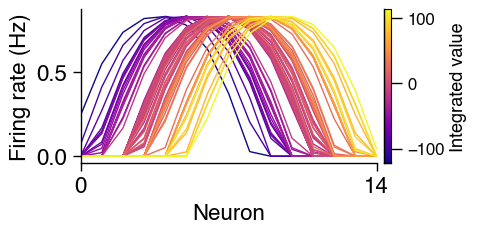

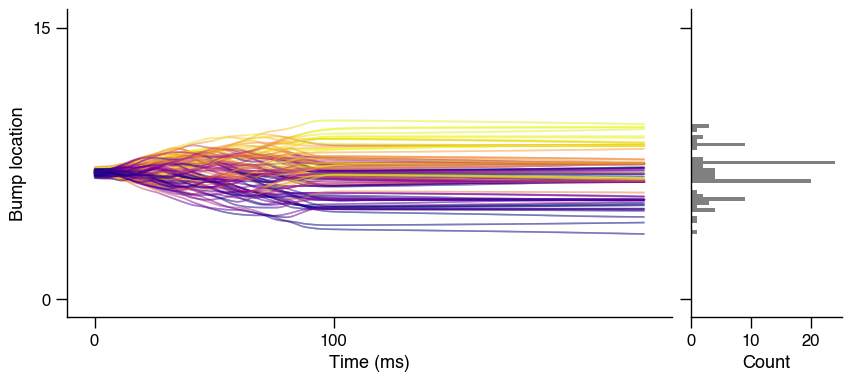

Axes(0.125,0.11;0.775x0.77)
Axes(0.125,0.11;0.775x0.77)
Axes(0.78375,0.11;0.11625x0.77)
Axes(0.125,0.11;0.64325x0.77)
Axes(0.125,0.11;0.604878x0.77)
Axes(0.74878,0.11;0.15122x0.77)


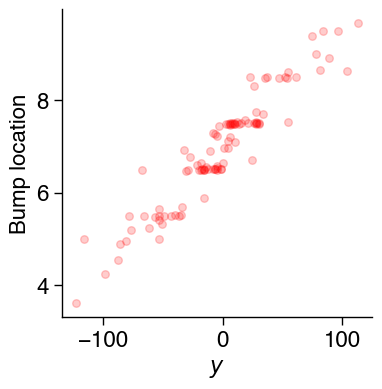

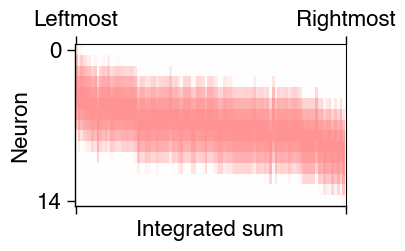

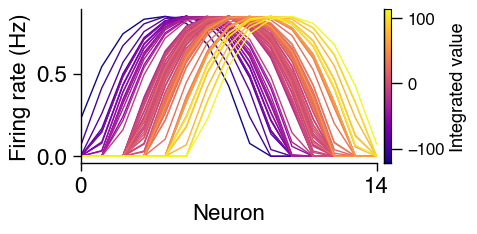

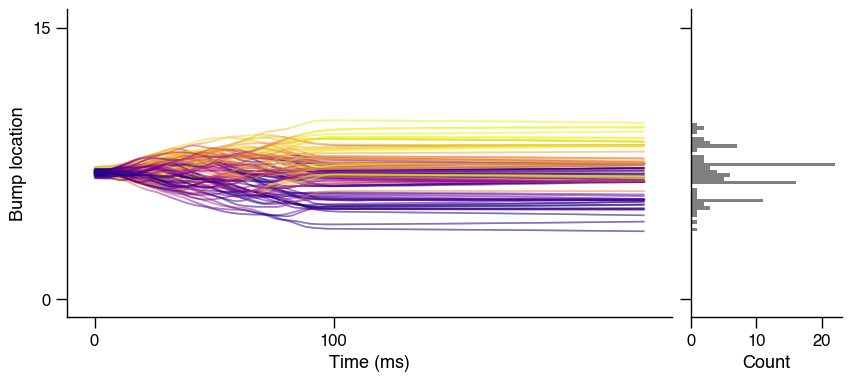

Axes(0.125,0.11;0.775x0.77)
Axes(0.125,0.11;0.775x0.77)
Axes(0.78375,0.11;0.11625x0.77)
Axes(0.125,0.11;0.64325x0.77)
Axes(0.125,0.11;0.604878x0.77)
Axes(0.74878,0.11;0.15122x0.77)


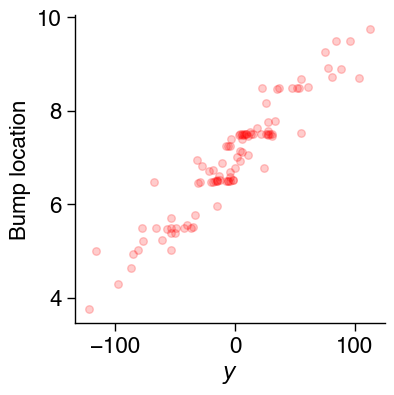

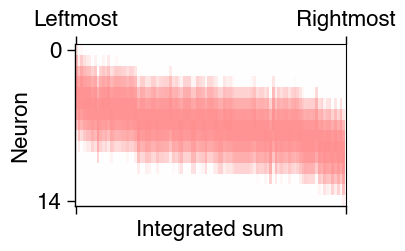

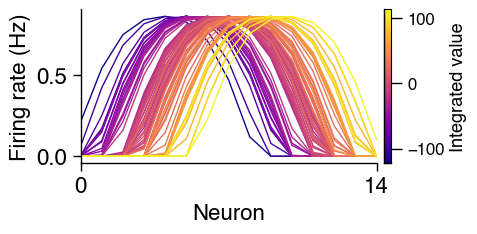

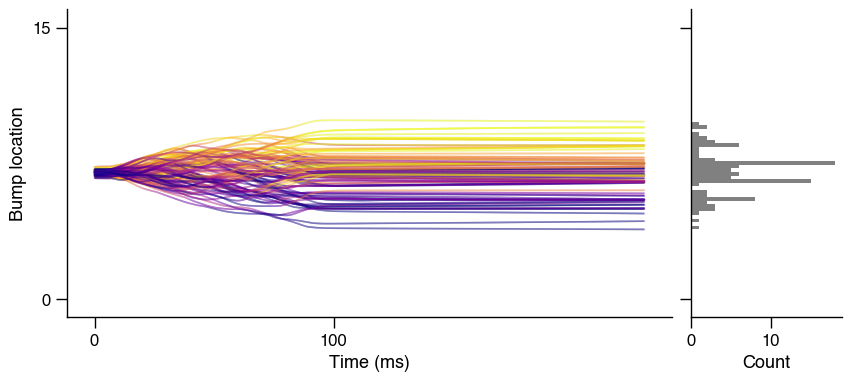

Axes(0.125,0.11;0.775x0.77)
Axes(0.125,0.11;0.775x0.77)
Axes(0.78375,0.11;0.11625x0.77)
Axes(0.125,0.11;0.64325x0.77)
Axes(0.125,0.11;0.604878x0.77)
Axes(0.74878,0.11;0.15122x0.77)


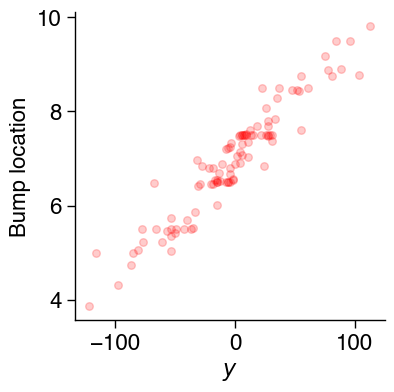

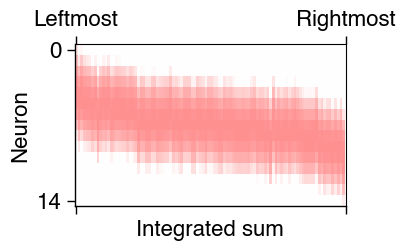

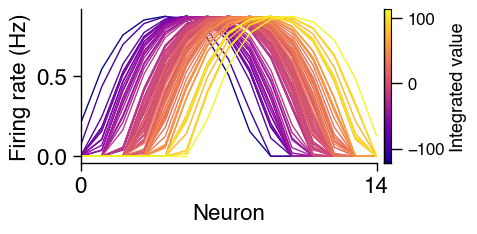

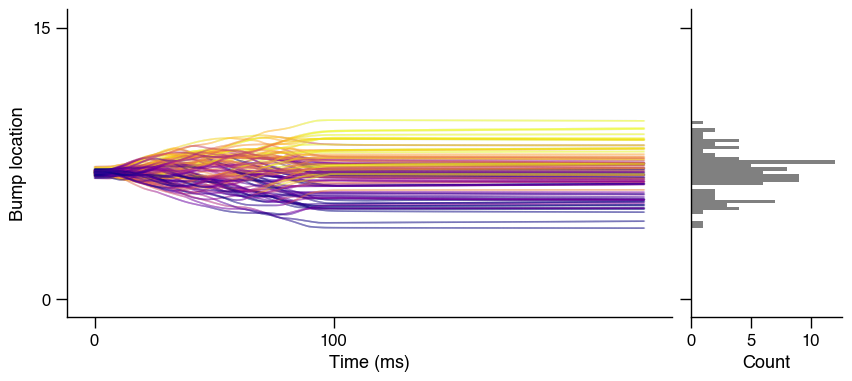

Axes(0.125,0.11;0.775x0.77)
Axes(0.125,0.11;0.775x0.77)
Axes(0.78375,0.11;0.11625x0.77)
Axes(0.125,0.11;0.64325x0.77)
Axes(0.125,0.11;0.604878x0.77)
Axes(0.74878,0.11;0.15122x0.77)


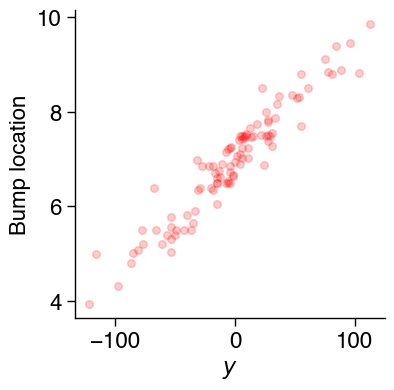

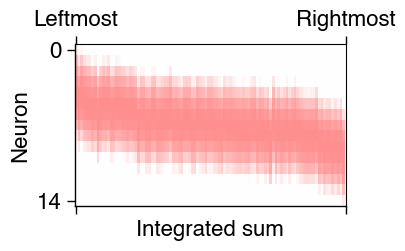

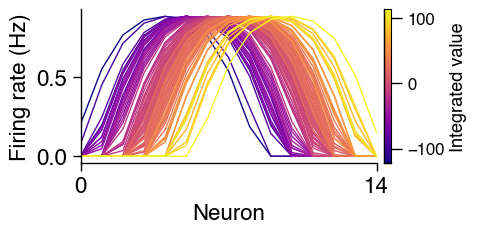

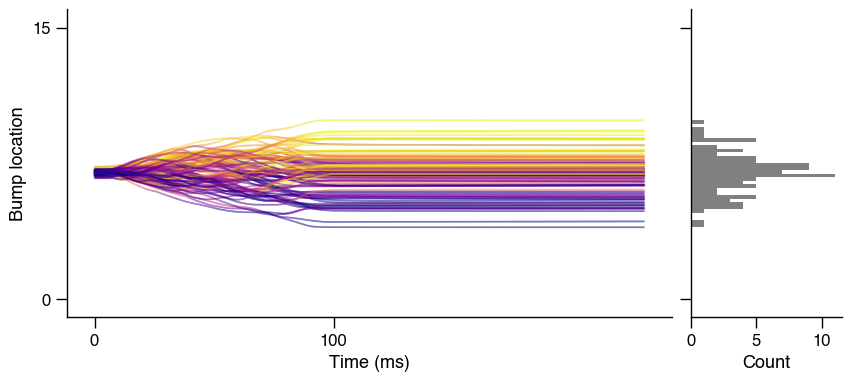

Axes(0.125,0.11;0.775x0.77)
Axes(0.125,0.11;0.775x0.77)
Axes(0.78375,0.11;0.11625x0.77)
Axes(0.125,0.11;0.64325x0.77)
Axes(0.125,0.11;0.604878x0.77)
Axes(0.74878,0.11;0.15122x0.77)


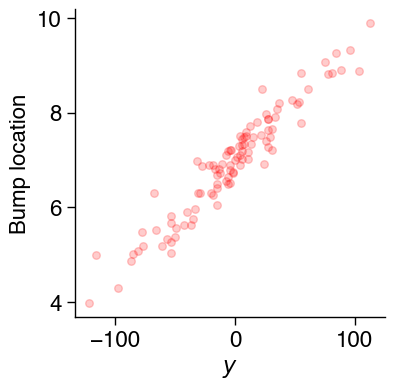

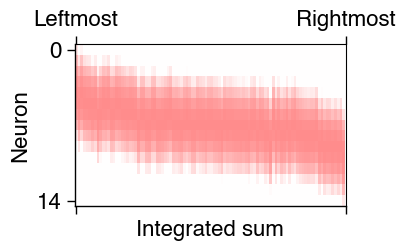

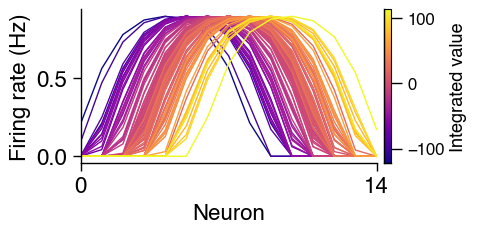

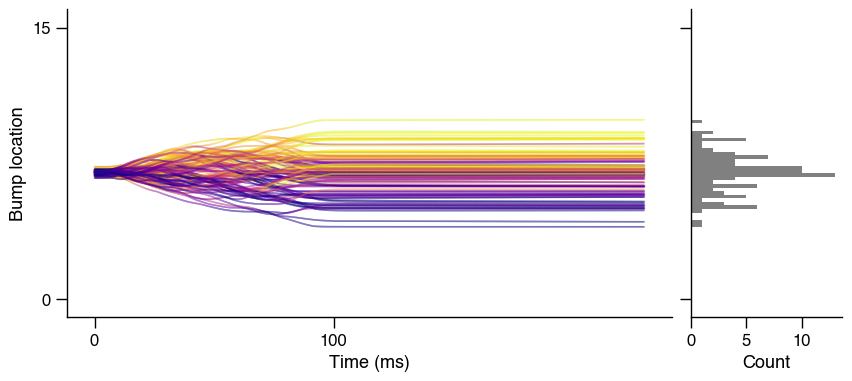

Axes(0.125,0.11;0.775x0.77)
Axes(0.125,0.11;0.775x0.77)
Axes(0.78375,0.11;0.11625x0.77)
Axes(0.125,0.11;0.64325x0.77)
Axes(0.125,0.11;0.604878x0.77)
Axes(0.74878,0.11;0.15122x0.77)


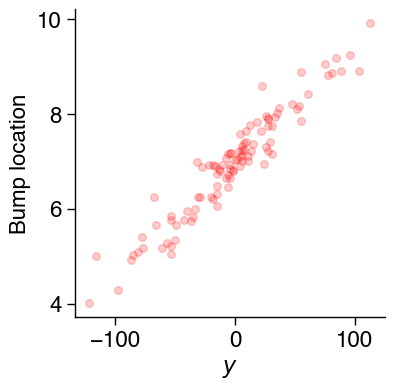

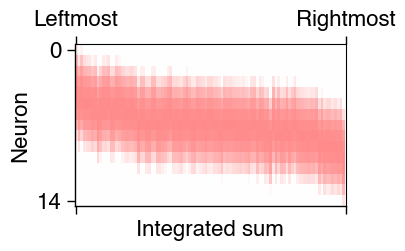

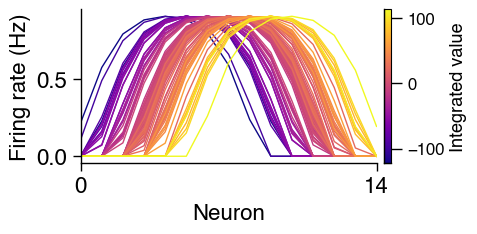

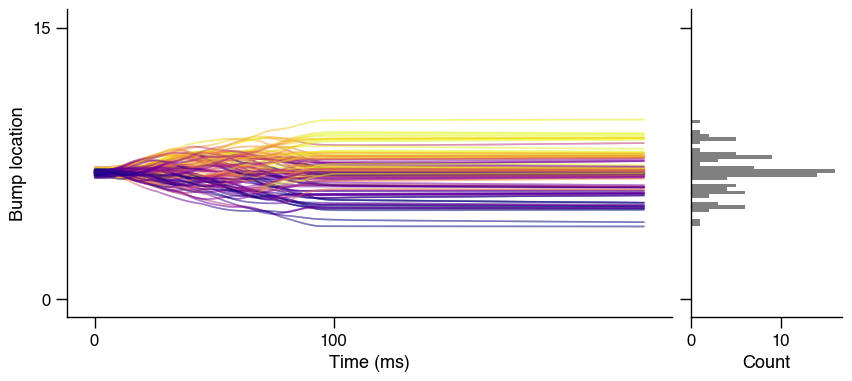

Axes(0.125,0.11;0.775x0.77)
Axes(0.125,0.11;0.775x0.77)
Axes(0.78375,0.11;0.11625x0.77)
Axes(0.125,0.11;0.64325x0.77)
Axes(0.125,0.11;0.604878x0.77)
Axes(0.74878,0.11;0.15122x0.77)


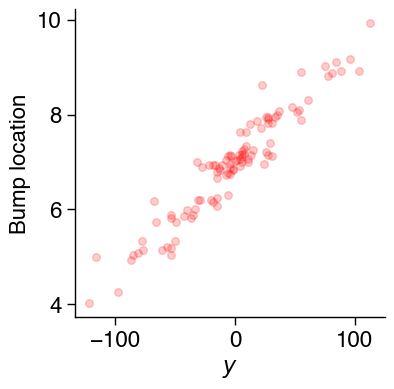

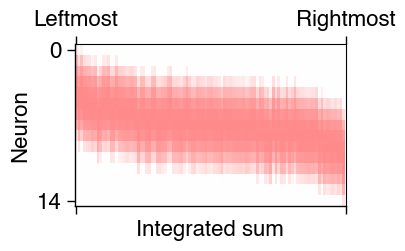

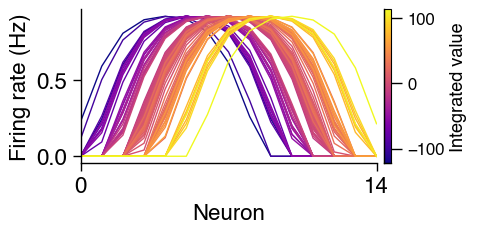

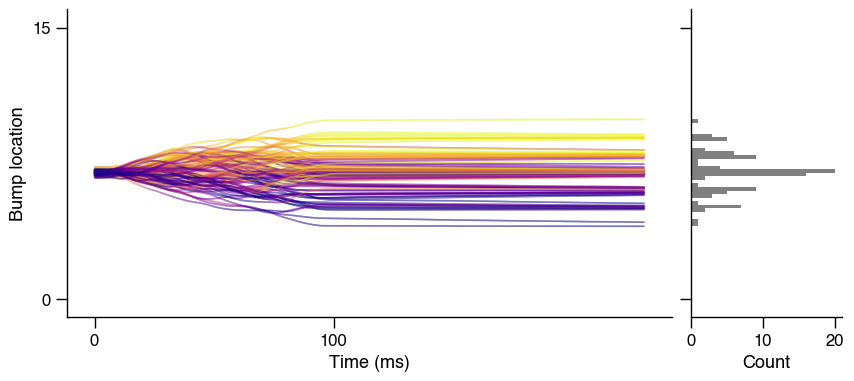

Axes(0.125,0.11;0.775x0.77)
Axes(0.125,0.11;0.775x0.77)
Axes(0.78375,0.11;0.11625x0.77)
Axes(0.125,0.11;0.64325x0.77)
Axes(0.125,0.11;0.604878x0.77)
Axes(0.74878,0.11;0.15122x0.77)


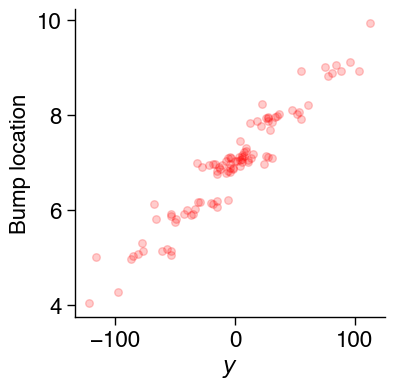

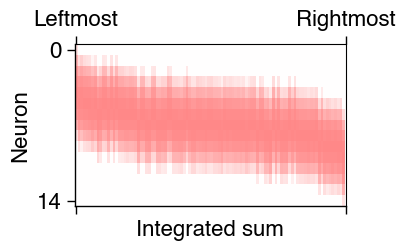

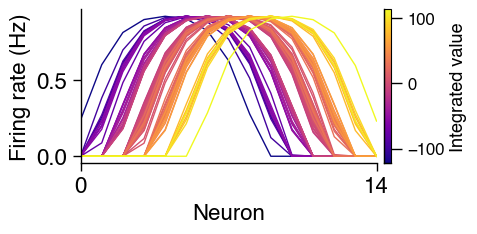

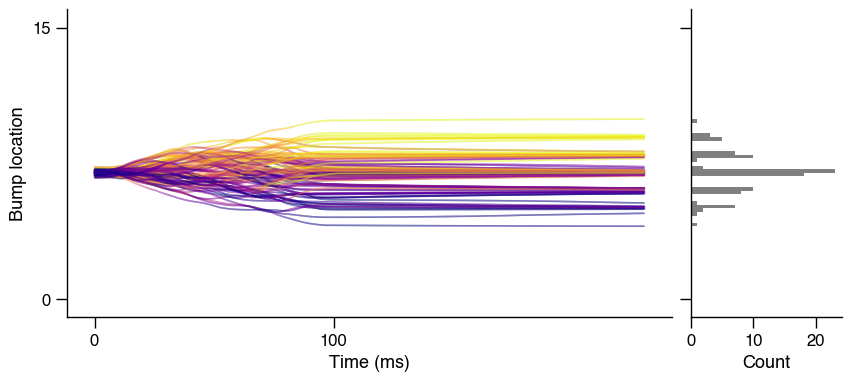

Axes(0.125,0.11;0.775x0.77)
Axes(0.125,0.11;0.775x0.77)
Axes(0.78375,0.11;0.11625x0.77)
Axes(0.125,0.11;0.64325x0.77)
Axes(0.125,0.11;0.604878x0.77)
Axes(0.74878,0.11;0.15122x0.77)


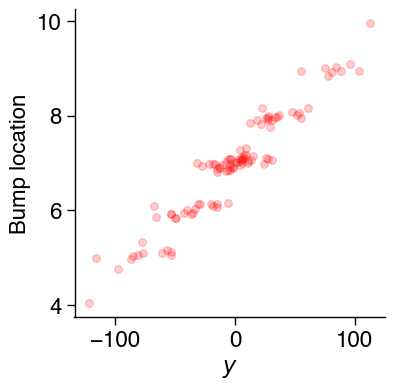

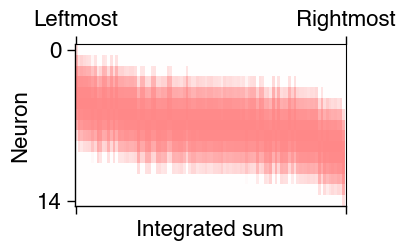

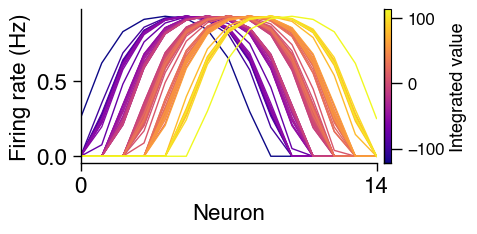

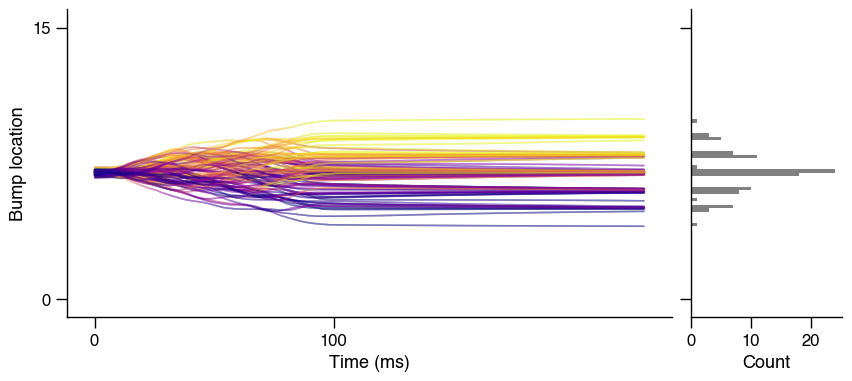

Axes(0.125,0.11;0.775x0.77)
Axes(0.125,0.11;0.775x0.77)
Axes(0.78375,0.11;0.11625x0.77)
Axes(0.125,0.11;0.64325x0.77)
Axes(0.125,0.11;0.604878x0.77)
Axes(0.74878,0.11;0.15122x0.77)


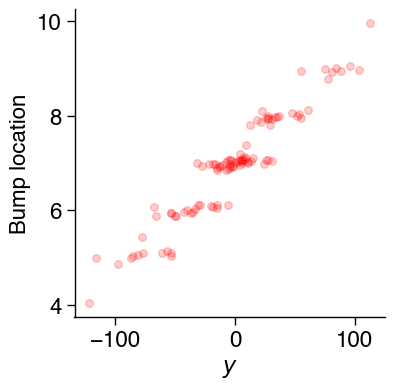

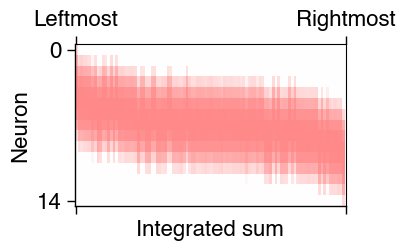

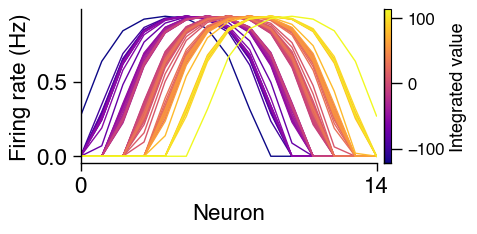

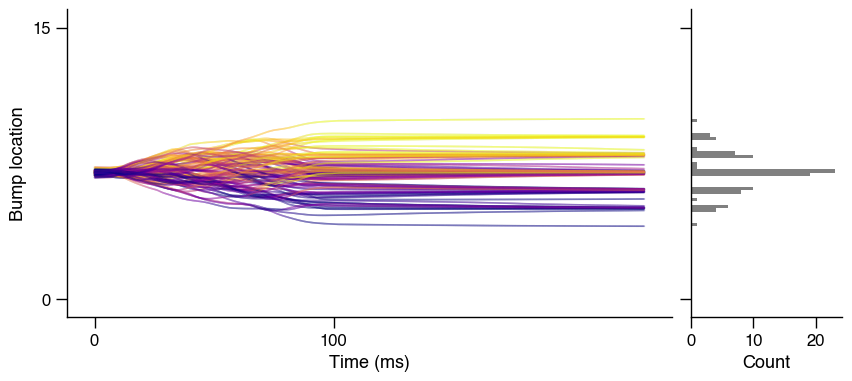

Axes(0.125,0.11;0.775x0.77)
Axes(0.125,0.11;0.775x0.77)
Axes(0.78375,0.11;0.11625x0.77)
Axes(0.125,0.11;0.64325x0.77)
Axes(0.125,0.11;0.604878x0.77)
Axes(0.74878,0.11;0.15122x0.77)


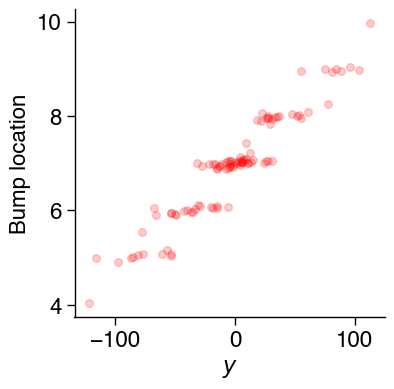

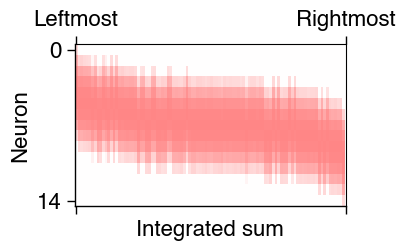

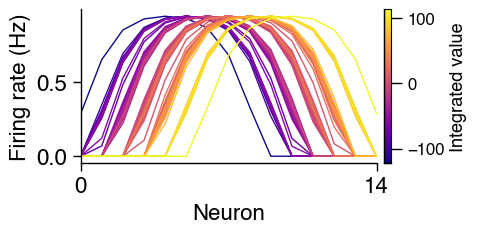

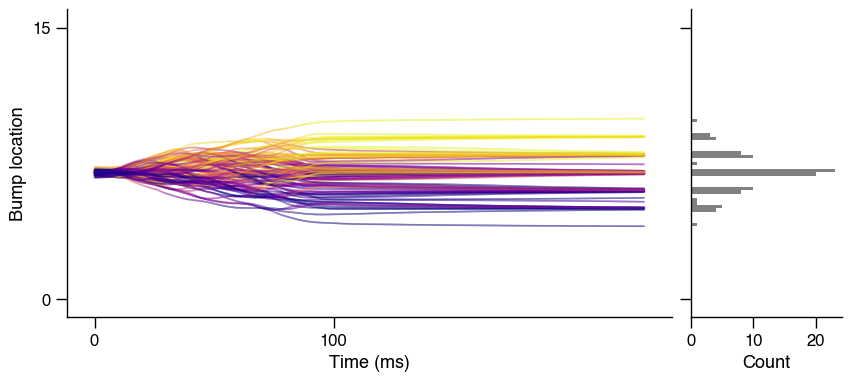

Axes(0.125,0.11;0.775x0.77)
Axes(0.125,0.11;0.775x0.77)
Axes(0.78375,0.11;0.11625x0.77)
Axes(0.125,0.11;0.64325x0.77)
Axes(0.125,0.11;0.604878x0.77)
Axes(0.74878,0.11;0.15122x0.77)


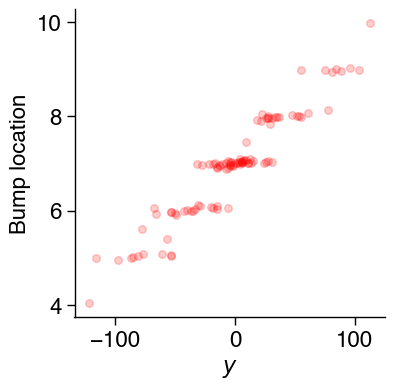

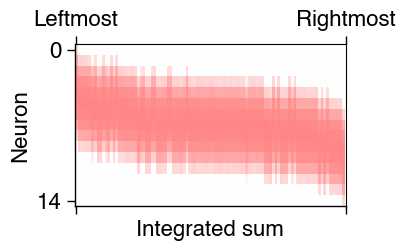

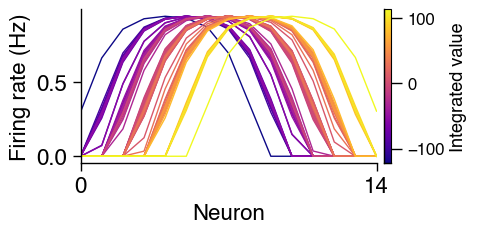

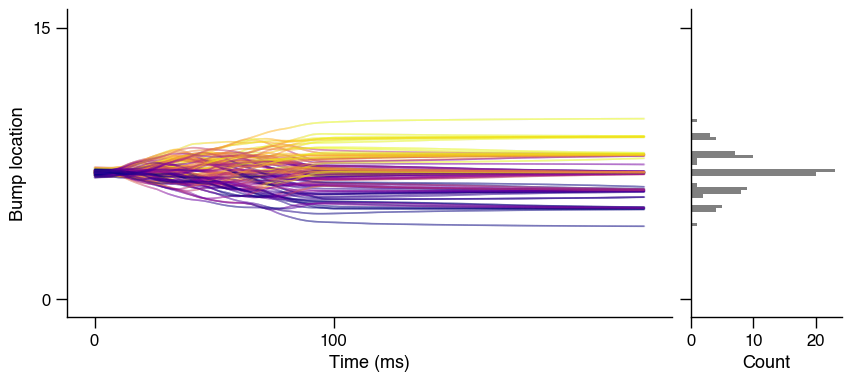

Axes(0.125,0.11;0.775x0.77)
Axes(0.125,0.11;0.775x0.77)
Axes(0.78375,0.11;0.11625x0.77)
Axes(0.125,0.11;0.64325x0.77)
Axes(0.125,0.11;0.604878x0.77)
Axes(0.74878,0.11;0.15122x0.77)


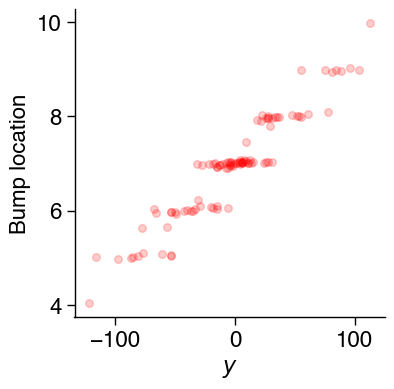

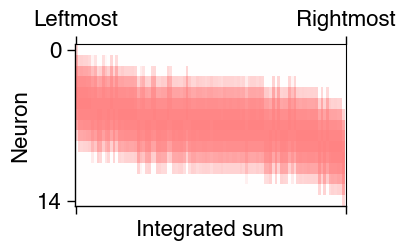

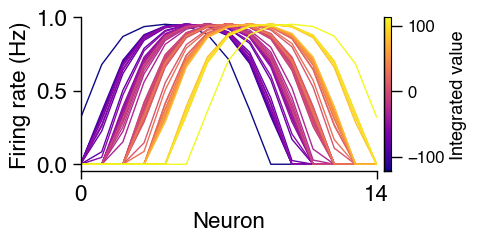

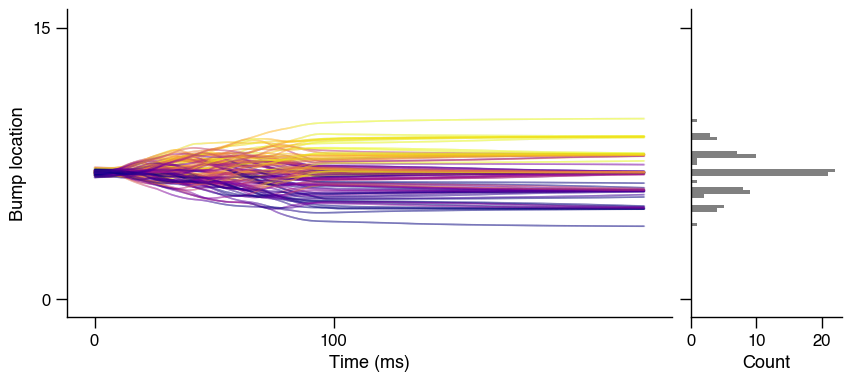

Axes(0.125,0.11;0.775x0.77)
Axes(0.125,0.11;0.775x0.77)
Axes(0.78375,0.11;0.11625x0.77)
Axes(0.125,0.11;0.64325x0.77)
Axes(0.125,0.11;0.604878x0.77)
Axes(0.74878,0.11;0.15122x0.77)


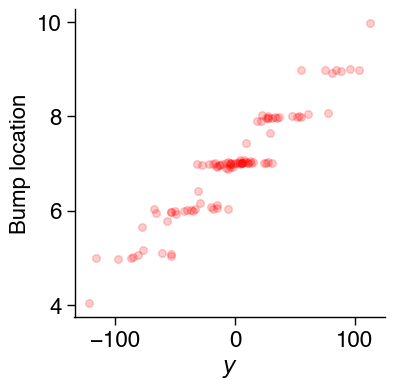

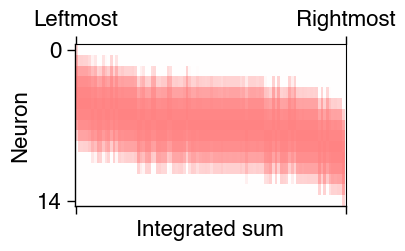

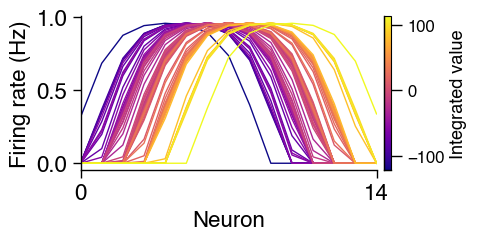

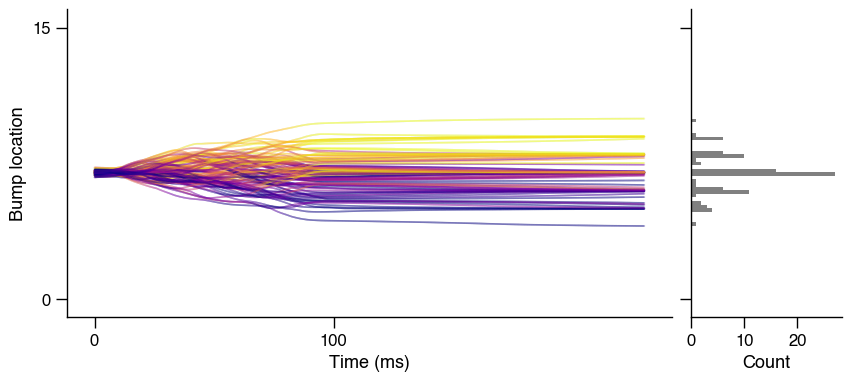

Axes(0.125,0.11;0.775x0.77)
Axes(0.125,0.11;0.775x0.77)
Axes(0.78375,0.11;0.11625x0.77)
Axes(0.125,0.11;0.64325x0.77)
Axes(0.125,0.11;0.604878x0.77)
Axes(0.74878,0.11;0.15122x0.77)


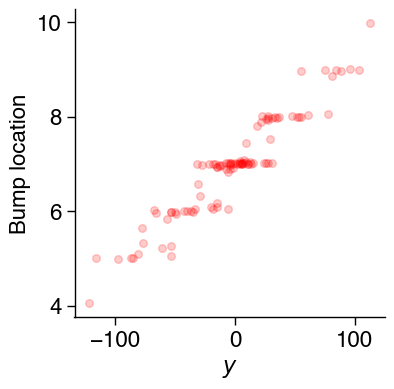

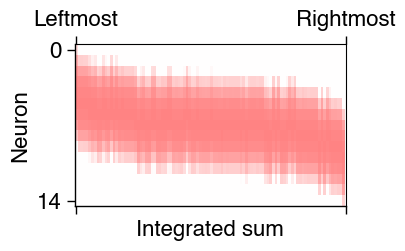

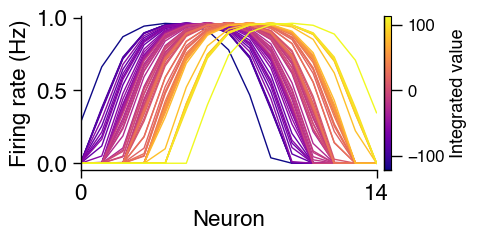

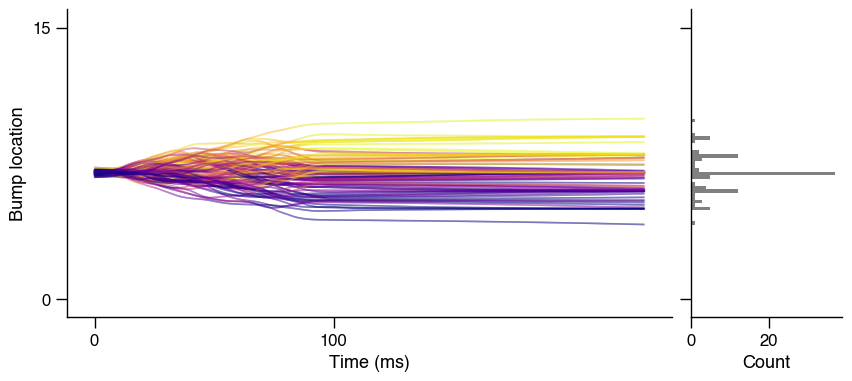

Axes(0.125,0.11;0.775x0.77)
Axes(0.125,0.11;0.775x0.77)
Axes(0.78375,0.11;0.11625x0.77)
Axes(0.125,0.11;0.64325x0.77)
Axes(0.125,0.11;0.604878x0.77)
Axes(0.74878,0.11;0.15122x0.77)


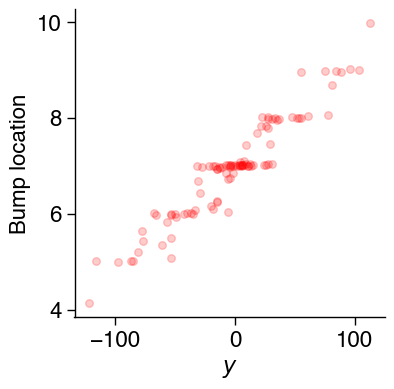

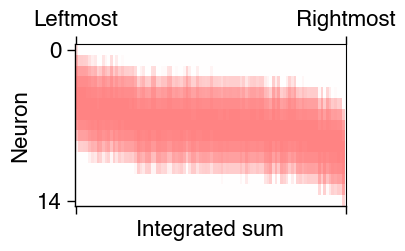

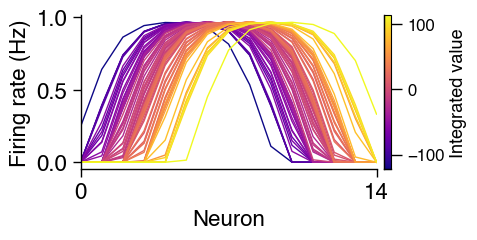

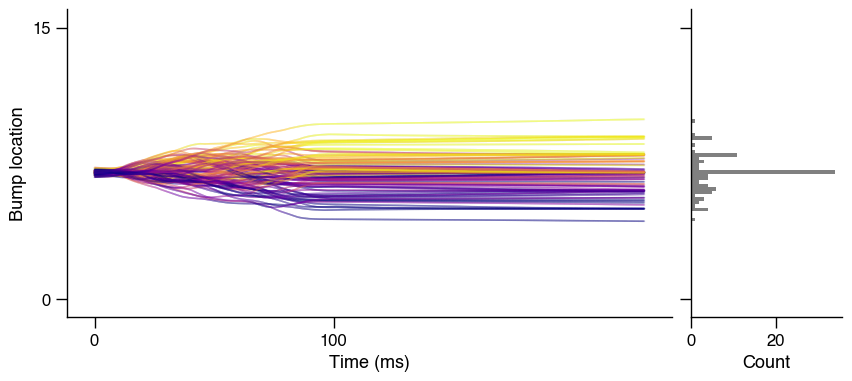

Axes(0.125,0.11;0.775x0.77)
Axes(0.125,0.11;0.775x0.77)
Axes(0.78375,0.11;0.11625x0.77)
Axes(0.125,0.11;0.64325x0.77)
Axes(0.125,0.11;0.604878x0.77)
Axes(0.74878,0.11;0.15122x0.77)


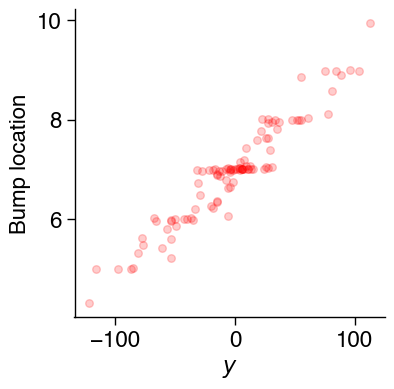

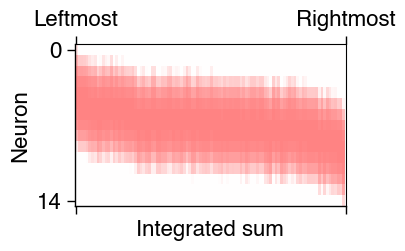

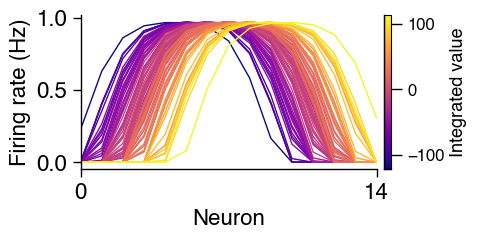

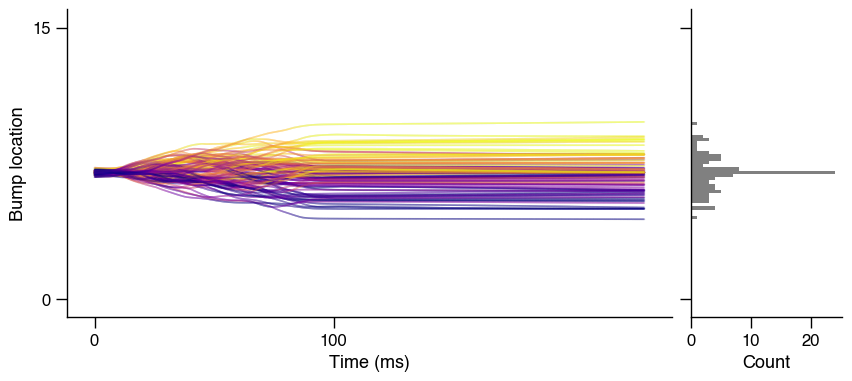

Axes(0.125,0.11;0.775x0.77)


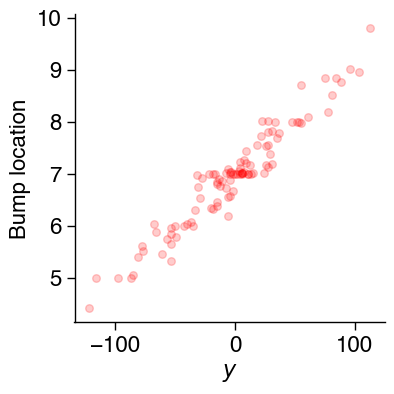

In [22]:
for dp in DATA_PATHS:
    for i in range(2,3):
        last_100_r, all_int_values = load_r_and_int_values(dp, f'net_00{i}_*.npy')
        make_tuning_curves(last_100_r, all_int_values)
        make_stability_plot(last_100_r, all_int_values)

In [15]:
import matplotlib.cm as cm
import matplotlib.colors as colors
import math

def make_tuning_curve_grid(last_100_r_all, all_int_values_all, labels=None, ncols=5):
    """
    Plot tuning curves for a series of networks in a rectangular grid (e.g., 5x4).
    
    Parameters
    ----------
    last_100_r_all : ndarray
        Shape (n_networks, n_neurons, n_trials, time)
    all_int_values_all : ndarray
        Shape (n_networks, n_trials, time)
    ncols : int
        Number of columns in the subplot grid
    """
    n_networks = last_100_r_all.shape[0]
    n_neurons = last_100_r_all.shape[1]
    nrows = math.ceil(n_networks / ncols)

    fig, axs = plt.subplots(nrows, ncols, figsize=(1.8 * ncols, 1.2 * nrows), sharex=True, sharey=True)
    axs = np.array(axs).reshape(-1)  # flatten in case of 1D row or column

    plasma = cm.get_cmap("plasma")

    # Use global color normalization for consistent coloring
    global_min = np.min(all_int_values_all[:, :, -250])
    global_max = np.max(all_int_values_all[:, :, -250])
    norm = colors.Normalize(vmin=global_min, vmax=global_max)

    for net_idx in range(n_networks):
        ax = axs[net_idx]
        last_100_r = last_100_r_all[net_idx]
        all_int_values = all_int_values_all[net_idx]

        sort_idx = np.argsort(all_int_values[:, -250])
        sorted_int_values = all_int_values[sort_idx, -250]
        sorted_activity = last_100_r[:, sort_idx, -250]

        color_vals = [plasma(norm(val))[:3] for val in sorted_int_values]

        for trial in range(sorted_activity.shape[1]):
            ax.plot(np.arange(n_neurons), sorted_activity[:, trial], color=color_vals[trial], lw=1)

        ax.set_xlim(0, n_neurons - 1)
        ax.tick_params(axis='both', labelsize=8, length=3)

        if labels is not None:
            ax.text(0.05, 1.2, labels[net_idx], transform=ax.transAxes, fontsize=8, va='top', ha='left', color='black')

    axs[0].set_ylabel("Firing rate (Hz)")
    axs[ncols * (nrows - 1)].set_xlabel("Neuron")

    # Hide unused subplots if n_networks < nrows * ncols
    for idx in range(n_networks, nrows * ncols):
        axs[idx].axis("off")

    # Add horizontal colorbar at top
    sm = cm.ScalarMappable(cmap=plasma, norm=norm)
    sm.set_array([])
    fig.subplots_adjust(top=0.88)
    cbar_ax = fig.add_axes([0.1, 0.99, 0.3, 0.015])
    cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
    cbar.set_label("Integrated value", fontsize=11)
    cbar.ax.tick_params(labelsize=9)

    format_plot(axs)
    format_plot(cbar_ax)

    fig.tight_layout(rect=[0, 0, 1, 0.88])
    return fig, axs

In [16]:
all_r_stack = []
int_values_stack = []
for dp in DATA_PATHS:
    for i in range(1,2):
        all_r, all_int_values = load_r_and_int_values(dp, f'net_00{i}_*.npy', last_n=None)
        all_r_stack.append(all_r)
        int_values_stack.append(all_int_values)
all_r_stack = np.stack(all_r_stack)
int_values_stack = np.stack(int_values_stack)

/tmp/ipykernel_1009104/453206794.py:25: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



[<Axes: ylabel='Firing rate (Hz)'> <Axes: > <Axes: > <Axes: > <Axes: >
 <Axes: > <Axes: > <Axes: > <Axes: > <Axes: > <Axes: > <Axes: > <Axes: >
 <Axes: > <Axes: > <Axes: > <Axes: > <Axes: > <Axes: > <Axes: >
 <Axes: xlabel='Neuron'> <Axes: > <Axes: > <Axes: > <Axes: >]
Axes(0.1,0.99;0.3x0.015)


/tmp/ipykernel_1009104/453206794.py:71: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



(<Figure size 900x600 with 26 Axes>,
 array([<Axes: ylabel='Firing rate (Hz)'>, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: xlabel='Neuron'>,
        <Axes: >, <Axes: >, <Axes: >, <Axes: >], dtype=object))

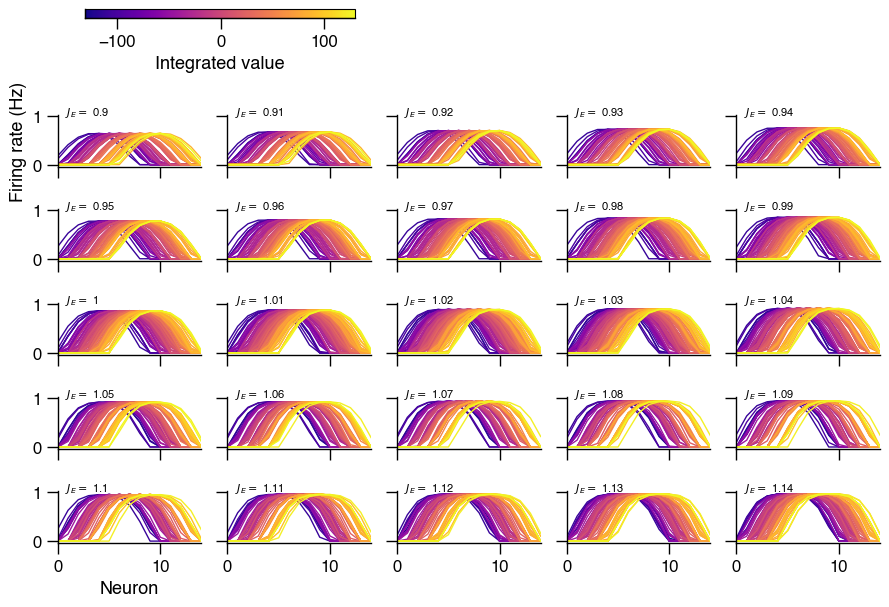

In [17]:
make_tuning_curve_grid(
    all_r_stack[:25, ...],
    int_values_stack[:25, ...],
    labels=[(r'$J_E =$ ' + f'{x:.3g}') for x in (np.arange(25) * 0.01 + 0.9)],
)

In [7]:
from scipy.stats import gaussian_kde

def test_representation_fidelity(all_r, all_int_values, n_fold=20, lasso_alpha=0.1):

    train_range = slice(0, 40)
    test_range = slice(40, 140)
    
    stacked_activities_train = all_r[:, train_range, :]
    y_train = all_int_values[train_range, :]
    stacked_activities_test = all_r[:, test_range, :]
    y_test = all_int_values[test_range, :]
    
    scores = []
    
    for i in range(n_fold):
        train_acts = np.random.randint(0, 40, size=8000)
        train_steps = np.random.randint(0, 2250, size=8000)
        test_acts = np.arange(100)
        test_steps = np.random.randint(0, 2250, size=100)
        
        X_train = stacked_activities_train[:, train_acts, train_steps + 50].T
        Y_train = y_train[train_acts, train_steps]

        kde = gaussian_kde(Y_train)
        
        X_test = stacked_activities_test[:, test_acts, test_steps + 50].T
        Y_test = y_test[test_acts, test_steps]
        
        reg = linear_model.Lasso(alpha=lasso_alpha).fit(X_train, Y_train, sample_weight=1 / kde(Y_train))
        score = reg.score(X_test, Y_test)
        scores.append(score)
    
    print(scores)
    print(np.mean(scores))

    scale = 0.8
    fig, axs = plt.subplots(1, 1, figsize=(4 * scale, 4 * scale))

    Y_hat = reg.predict(X_test)

    m = 1.05 * np.max(np.abs(np.concatenate([Y_test, Y_hat])))
    
    axs.plot([-m, m], [-m, m], color='black', zorder=0)
    axs.scatter(Y_test, Y_hat, s=30, zorder=1, facecolor='none', edgecolor='red', alpha=0.5)
    axs.set_xlim(-m, m)
    axs.set_ylim(-m, m)
    axs.set_xticks([-100, 0, 100])
    axs.set_yticks([-100, 0, 100])
    
    format_plot(axs)
    
    axs.set_xlabel(r'$y$', fontsize=16)
    axs.set_ylabel(r'$\hat{y}$', fontsize=16)
    axs.set_title('Predicted vs true integrated sums', fontsize=16)
    axs.tick_params(axis='both', length=6, labelsize=16)

    return np.mean(scores)

[0.8701861650714117, 0.8476464777573722, 0.8636577583401848, 0.8655697983093058, 0.8638313979294293, 0.8743885318861051, 0.8838253425583883, 0.8685040829644586, 0.8325024753334065, 0.874207148690189, 0.8912770018787742, 0.8430678179986704, 0.8656039194616678, 0.8736722189526653, 0.8774495831542787, 0.8663758952466136, 0.8648669961112814, 0.8706907697922696, 0.8528293432785101, 0.8942296628832488]
0.8672191193799115
Axes(0.125,0.11;0.775x0.77)
[0.8593973884704869, 0.8747479515919707, 0.870780979732944, 0.8776714390932738, 0.8780081221503385, 0.8710576803393407, 0.8539135489969492, 0.8629641095148464, 0.8968741348640679, 0.8970285191910167, 0.8572628796484839, 0.8634302897643559, 0.8699068581370341, 0.8854115850041183, 0.8559948378548734, 0.8666629891598884, 0.8788147673968059, 0.8925738028109736, 0.8561961272661951, 0.899179928485457]
0.8733938969736709
Axes(0.125,0.11;0.775x0.77)
[0.8829777854764841, 0.8835627632299462, 0.8839587172387797, 0.8712485627120892, 0.8612982077819968, 0.8920

/tmp/ipykernel_928298/128768580.py:37: RuntimeWarning:

More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.



[0.9140529962184243, 0.9125244237018867, 0.9155351121373777, 0.9239573738200477, 0.9228391094592323, 0.9059134336488818, 0.9211461778574176, 0.92391283938515, 0.9228008714323269, 0.9118799272217049, 0.9097841145582996, 0.9128392976414071, 0.8984311451629848, 0.9184722174461876, 0.9063068994017975, 0.9075493855468377, 0.9200252272032003, 0.9144537581783292, 0.921964041571376, 0.9090348758708635]
0.9146711613731867
Axes(0.125,0.11;0.775x0.77)
[0.9239071661028765, 0.9137798906759549, 0.9240196469976071, 0.9185916063530191, 0.904344687045627, 0.924430550460041, 0.9139044116543044, 0.9072137947100627, 0.9248850373087294, 0.9188029339785416, 0.9201821647409498, 0.9287849108272225, 0.9148193880911539, 0.9026220793769469, 0.929618343921309, 0.9233325211456855, 0.904633210051956, 0.9173644236057528, 0.8994322362973152, 0.9218551704627408]
0.91682620869039
Axes(0.125,0.11;0.775x0.77)
[0.9161481869062446, 0.911355169825844, 0.9239677410448366, 0.9109127269662844, 0.9210469128385566, 0.93044823029

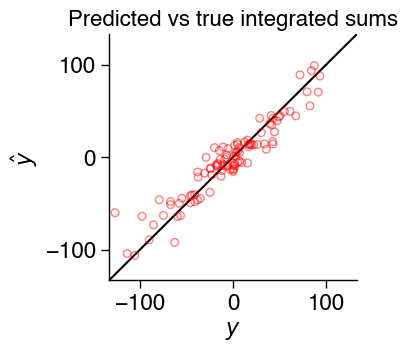

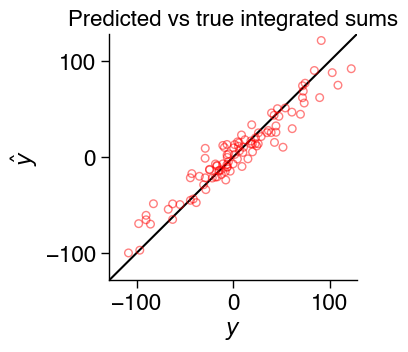

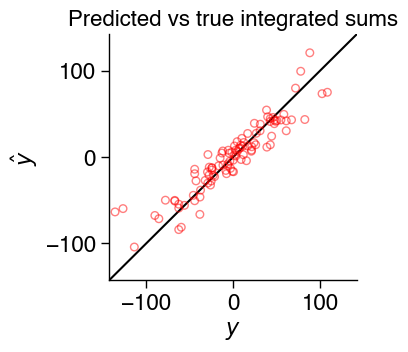

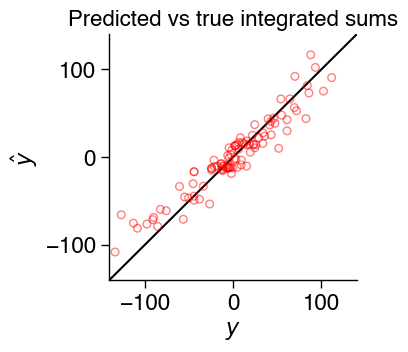

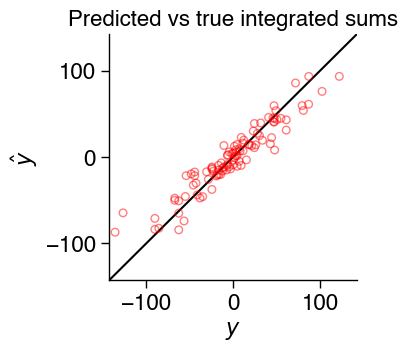

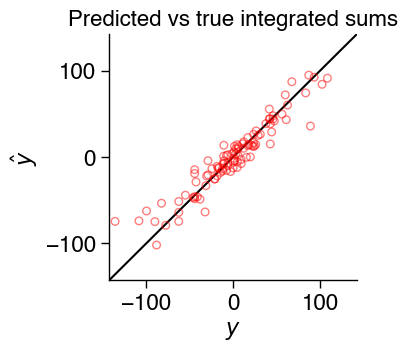

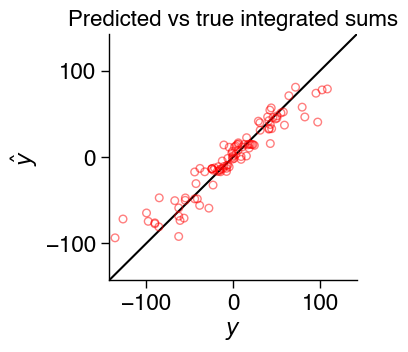

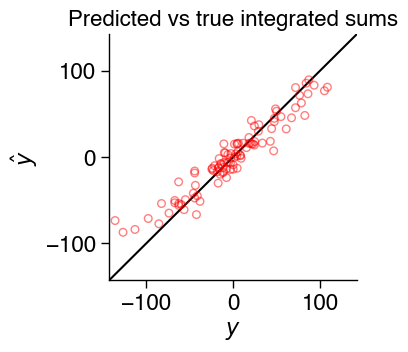

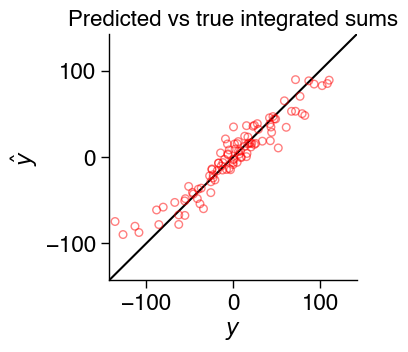

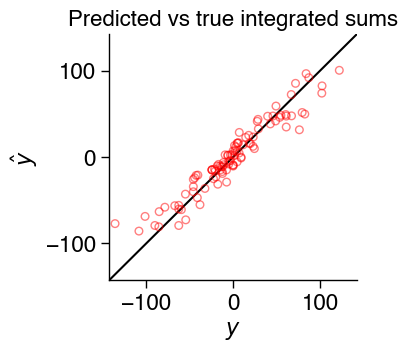

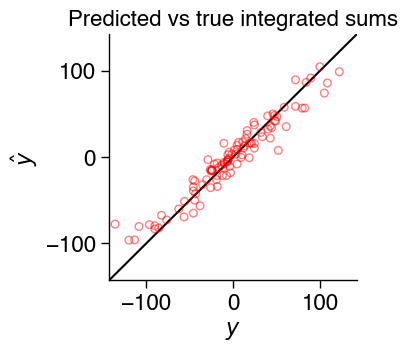

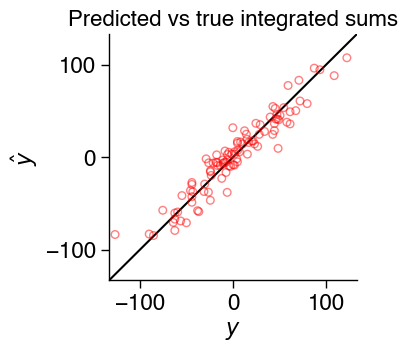

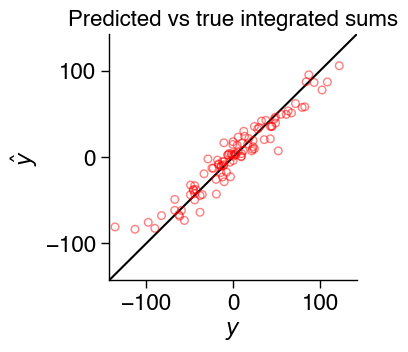

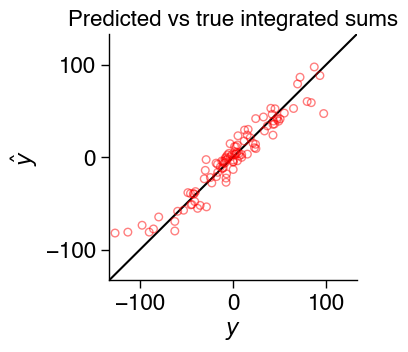

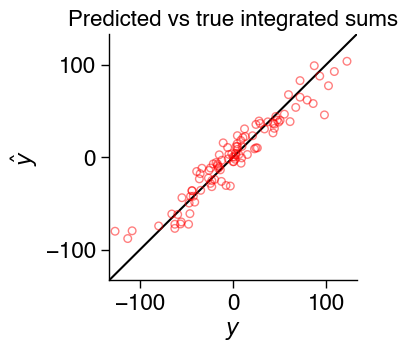

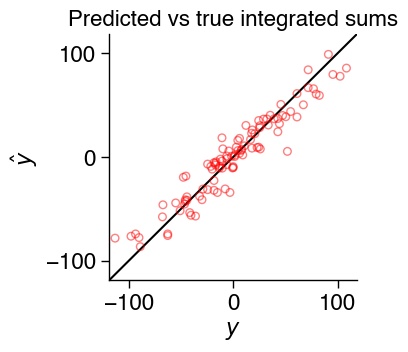

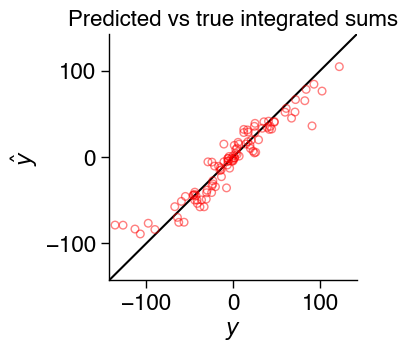

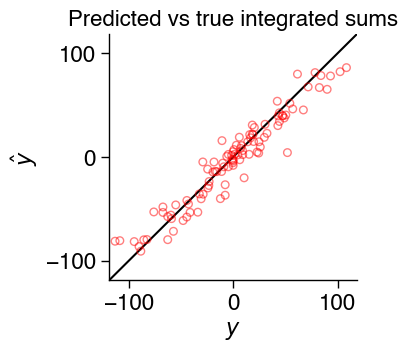

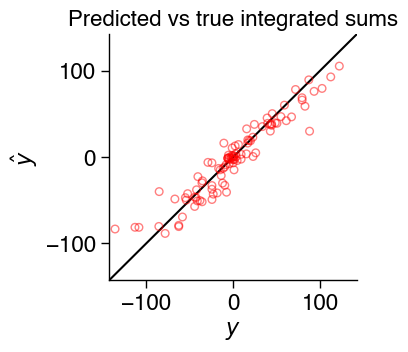

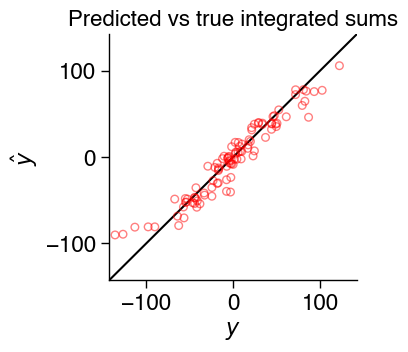

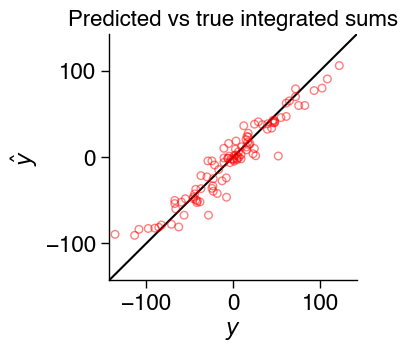

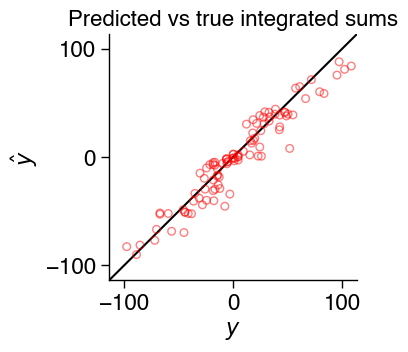

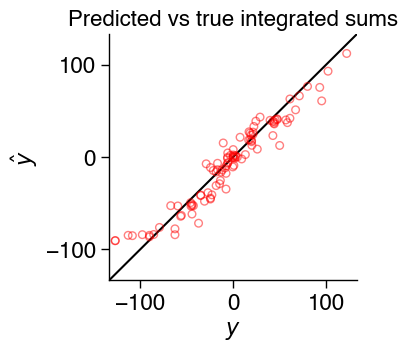

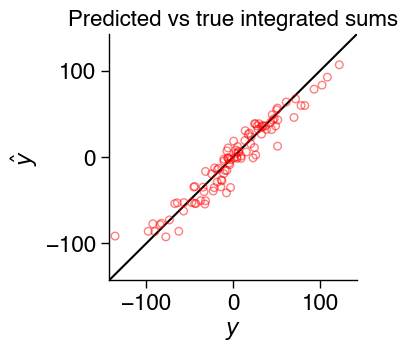

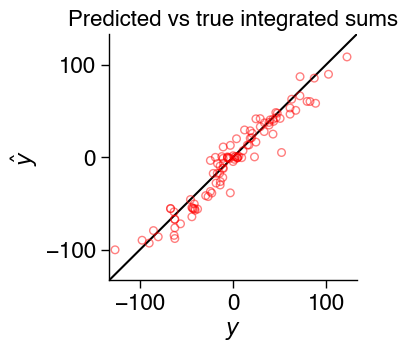

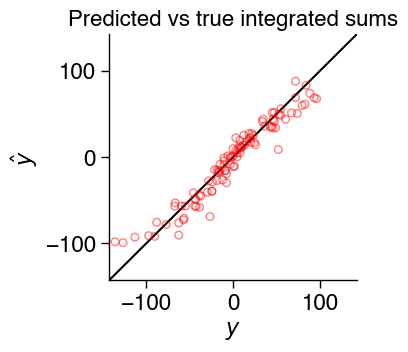

In [5]:
all_scores = []
for dp in DATA_PATHS:
    for i in range(1):
        all_r, all_int_values = load_r_and_int_values(dp, f'net_00{i}_*.npy', last_n=None)
        score = test_representation_fidelity(all_r, all_int_values)
        all_scores.append(score)

26
Axes(0.125,0.11;0.775x0.77)


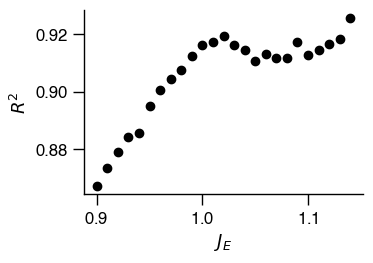

In [7]:
scale = 0.6
fig, axs = plt.subplots(1, 1, figsize=(6 * scale, 4 * scale))

print(len(all_scores))

axs.scatter(np.arange(25) * 0.01 + 0.9, all_scores[:25], c='black')
axs
axs.set_ylabel(r'$R^2$')
axs.set_xlabel(r'$J_E$')

axs.xaxis.set_major_formatter(matplotlib.ticker.ScalarFormatter(useMathText=True))
axs.ticklabel_format(style='sci', axis='x', scilimits=(0, 0))

format_plot(axs)

[0.7247022724965294, 0.7394988736493018, 0.7220314324957593]
0.72874419288053
Axes(0.125,0.11;0.775x0.77)
[0.7146603409710366, 0.710686251707394, 0.7026006993307768]
0.7093157640030691
Axes(0.125,0.11;0.775x0.77)
[0.7008833204442264, 0.7795626159692558, 0.7812493497868407]
0.753898428733441
Axes(0.125,0.11;0.775x0.77)
[0.7121744904726129, 0.6820741327588979, 0.736579817948789]
0.7102761470601
Axes(0.125,0.11;0.775x0.77)
[0.7183265940687082, 0.7761285803742314, 0.7606738473484415]
0.7517096739304603
Axes(0.125,0.11;0.775x0.77)
[0.7703694952067676, 0.7349292061569832, 0.7139814627817674]
0.7397600547151728
Axes(0.125,0.11;0.775x0.77)
[0.7919995748758293, 0.7654147757382012, 0.7812735203309198]
0.7795626236483167
Axes(0.125,0.11;0.775x0.77)
[0.6992028713708727, 0.7846511497815741, 0.7898606569916788]
0.7579048927147086
Axes(0.125,0.11;0.775x0.77)
[0.7064891546488465, 0.709372059687067, 0.7662466199670211]
0.7273692781009782
Axes(0.125,0.11;0.775x0.77)
[0.7563770491995989, 0.73960051836451

/tmp/ipykernel_1009104/1135425872.py:37: RuntimeWarning:

More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.



[0.8651462224929695, 0.8412610921846172, 0.8289612693285869]
0.8451228613353913
Axes(0.125,0.11;0.775x0.77)
[0.8528150051771667, 0.8272384573920295, 0.8421556345050369]
0.8407363656914111
Axes(0.125,0.11;0.775x0.77)
[0.825999692061938, 0.8456154515605467, 0.8381790431957968]
0.8365980622727606
Axes(0.125,0.11;0.775x0.77)
[0.819596628689065, 0.8430351567048219, 0.8486352296204711]
0.837089005004786
Axes(0.125,0.11;0.775x0.77)
[0.8647312928718784, 0.8396831983713582, 0.8603483040610191]
0.8549209317680853
Axes(0.125,0.11;0.775x0.77)


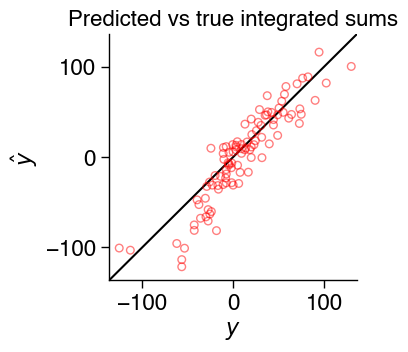

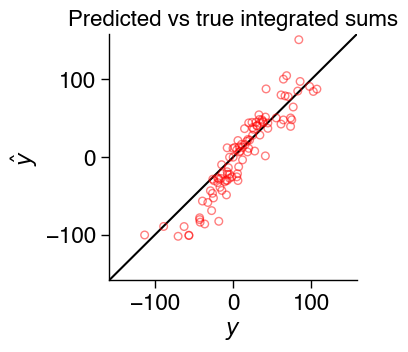

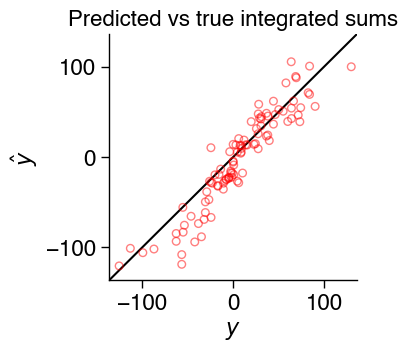

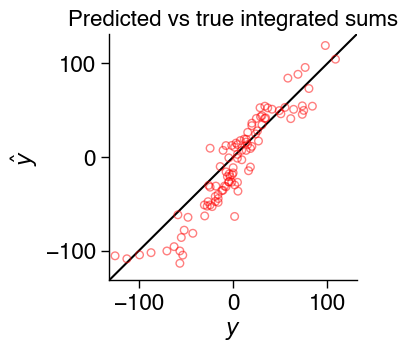

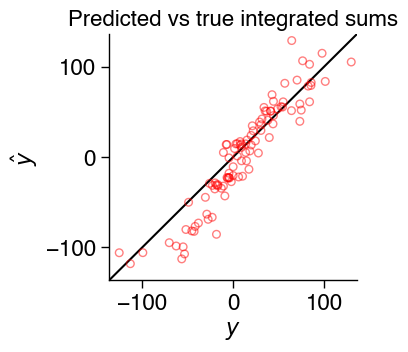

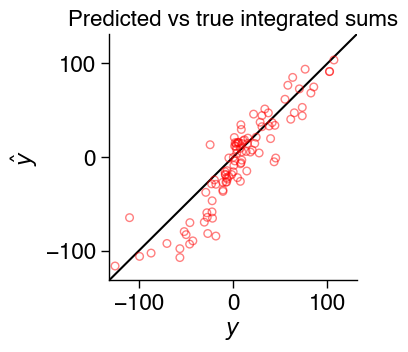

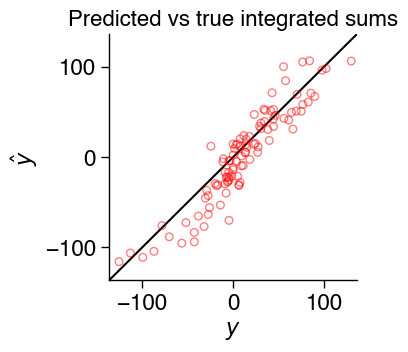

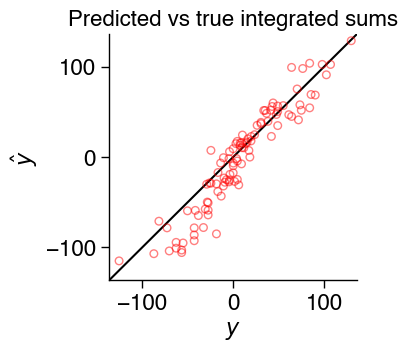

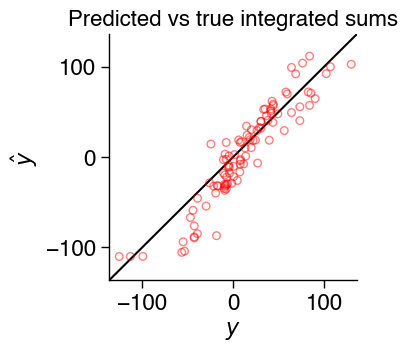

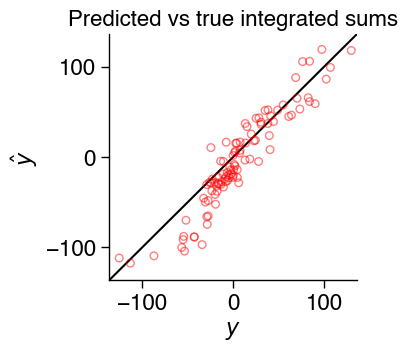

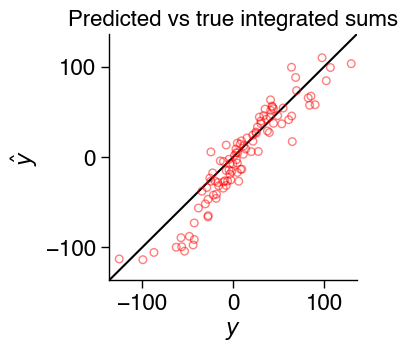

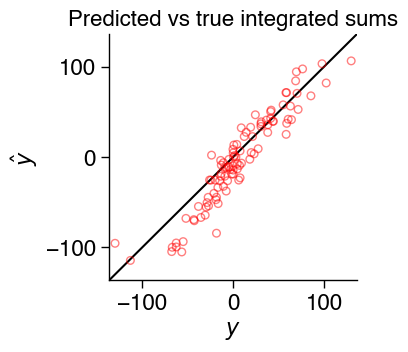

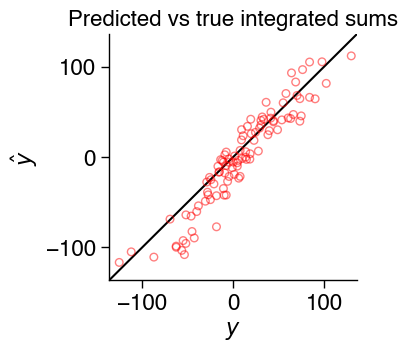

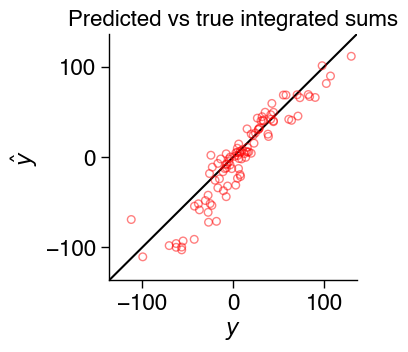

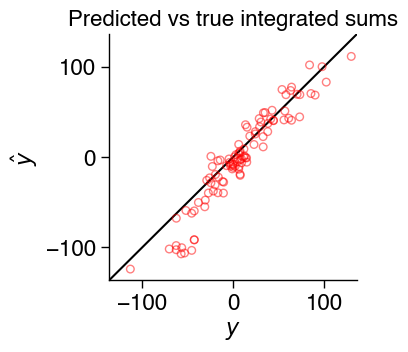

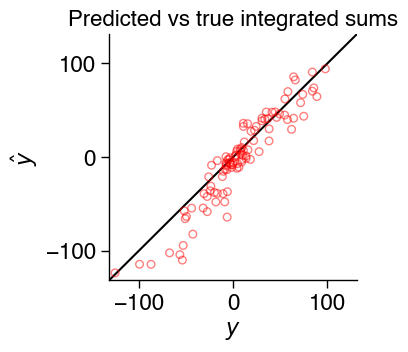

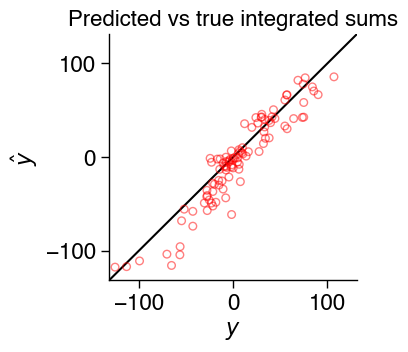

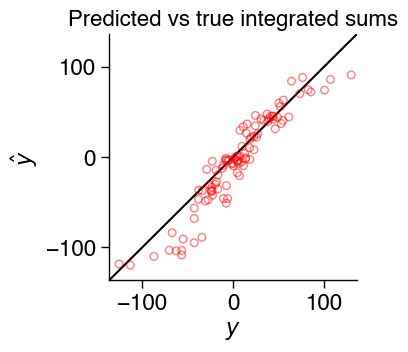

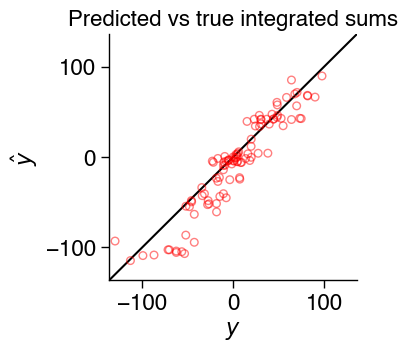

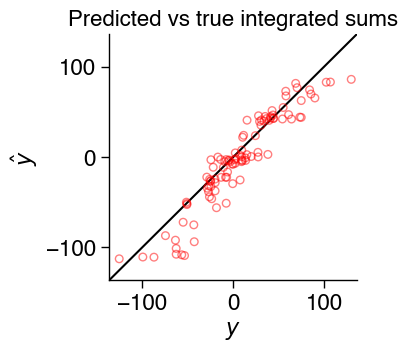

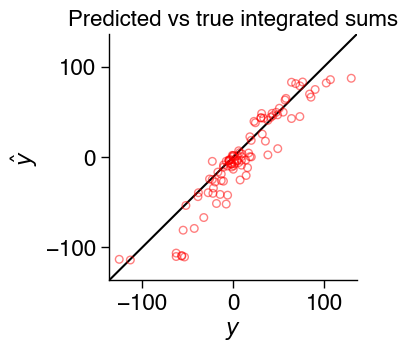

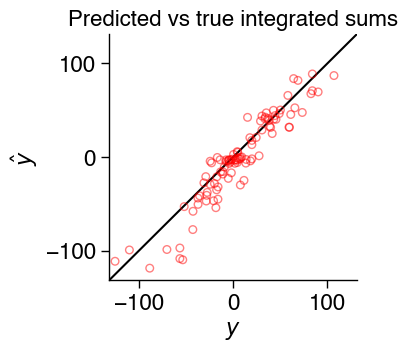

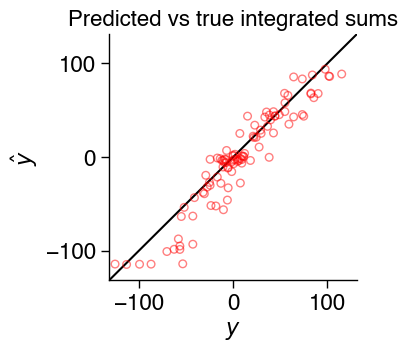

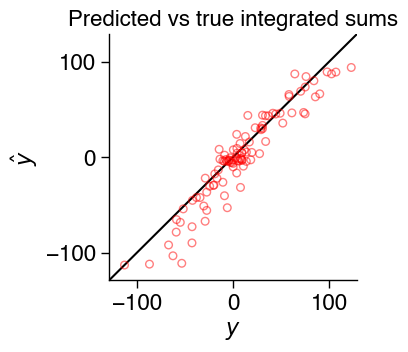

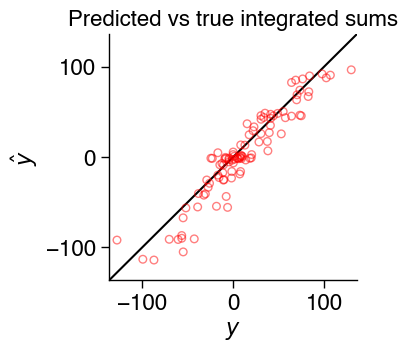

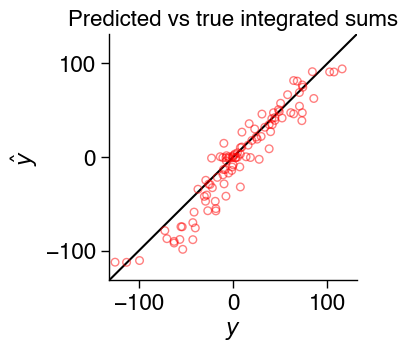

In [11]:
all_scores_prime = []
for dp in DATA_PATHS:
    for i in range(1, 2):
        all_r, all_int_values = load_r_and_int_values(dp, f'net_00{i}_*.npy', last_n=None)
        score = test_representation_fidelity(all_r, all_int_values, n_fold=3, lasso_alpha=0.05)
        all_scores_prime.append(score)

26
Axes(0.125,0.11;0.775x0.77)


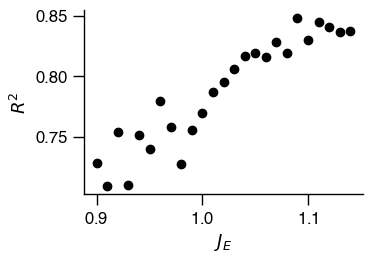

In [12]:
scale = 0.6
fig, axs = plt.subplots(1, 1, figsize=(6 * scale, 4 * scale))

print(len(all_scores_prime))

axs.scatter(np.arange(25) * 0.01 + 0.9, all_scores_prime[:25], c='black')
axs
axs.set_ylabel(r'$R^2$')
axs.set_xlabel(r'$J_E$')

axs.xaxis.set_major_formatter(matplotlib.ticker.ScalarFormatter(useMathText=True))
axs.ticklabel_format(style='sci', axis='x', scilimits=(0, 0))

format_plot(axs)